In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
data_df = pd.read_csv('/content/quickcart_ecommerce_orders.csv')
data_df.head(5)

,order_id,order_date,customer_id,customer_state,customer_city,city_tier,customer_age,customer_segment,acquisition_channel,device_type,...,profit_inr,promised_delivery_days,actual_delivery_days,delivery_status,order_status,return_flag,return_reason,rating,coupon_code,campaign_id
0,QC25020800001,2025-02-08,C06480,Bihar,Patna,Tier 2,39.0,Returning,Direct,Mobile,...,1171.13,6,8,Delayed,Delivered,0,NaN,5.0,SAVE10,CMP-09
1,QC25071900002,2025-07-19,C06197,Uttar Pradesh,Lucknow,Tier 2,22.0,Returning,Email,Mobile,...,1900.27,6,5,On Time,Delivered,0,NaN,4.0,FESTIVE20,CMP-03
2,QC25112100003,2025-11-21,C02829,Karnataka,Mangaluru,Tier 3,44.0,Returning,Affiliate,Mobile,...,1457.98,3,4,Delayed,Delivered,0,NaN,4.0,SAVE10,CMP-04
3,QC25032500004,2025-03-25,C04132,Kerala,Thiruvananthapuram,Tier 3,18.0,Returning,Direct,Mobile,...,2348.80,4,3,On Time,Delivered,0,NaN,4.0,NaN,CMP-09
4,QC25112800005,2025-11-28,C01137,Maharashtra,Nagpur,Tier 2,35.0,VIP,Paid Search,Desktop,...,1152.16,8,8,On Time,Delivered,0,NaN,5.0,SAVE10,CMP-10


#**Data Audit**







###1. Basic structural/scheme check




In [3]:
data_df.shape

(30035, 37)

In [4]:
print(data_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30035 entries, 0 to 30034
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 30035 non-null  object 
 1   order_date               30035 non-null  object 
 2   customer_id              30035 non-null  object 
 3   customer_state           30035 non-null  object 
 4   customer_city            30035 non-null  object 
 5   city_tier                30035 non-null  object 
 6   customer_age             29696 non-null  float64
 7   customer_segment         30035 non-null  object 
 8   acquisition_channel      30035 non-null  object 
 9   device_type              30035 non-null  object 
 10  product_id               30035 non-null  object 
 11  category                 30035 non-null  object 
 12  seller_id                30035 non-null  object 
 13  seller_tier              29916 non-null  object 
 14  warehouse             

In [5]:
data_dict = pd.read_csv('/content/quickcart_data_dictionary.csv')
data_dict.head()

,column_name,description,example_or_range,data_type
0,order_id,Unique order identifier,QC...,Identifier
1,order_date,Order placement date,YYYY-MM-DD,Date
2,customer_id,Customer identifier,C00001,Identifier
3,customer_state,Customer state,Maharashtra,Categorical
4,customer_city,Customer city,Mumbai,Categorical


In [6]:
data_dict

,column_name,description,example_or_range,data_type
0,order_id,Unique order identifier,QC...,Identifier
1,order_date,Order placement date,YYYY-MM-DD,Date
2,customer_id,Customer identifier,C00001,Identifier
3,customer_state,Customer state,Maharashtra,Categorical
4,customer_city,Customer city,Mumbai,Categorical
5,city_tier,Customer city tier,Tier 1/2/3,Categorical
6,customer_age,Customer age; small missingness intentional,18-68,Numeric
7,customer_segment,Customer segment at order time,New/Returning/VIP,Categorical
8,acquisition_channel,Primary acquisition channel,Organic/Paid/Social/...,Categorical
9,device_type,Device used,Mobile/Desktop/Tablet,Categorical


*   **order_date** is *obj* in the data file,needs to be converted to the appropriate data type for proper analysis further.


In [7]:
data_df['order_date'] = pd.to_datetime(data_df['order_date'])
print(data_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30035 entries, 0 to 30034
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_id                 30035 non-null  object        
 1   order_date               30035 non-null  datetime64[ns]
 2   customer_id              30035 non-null  object        
 3   customer_state           30035 non-null  object        
 4   customer_city            30035 non-null  object        
 5   city_tier                30035 non-null  object        
 6   customer_age             29696 non-null  float64       
 7   customer_segment         30035 non-null  object        
 8   acquisition_channel      30035 non-null  object        
 9   device_type              30035 non-null  object        
 10  product_id               30035 non-null  object        
 11  category                 30035 non-null  object        
 12  seller_id                30035 n

In [8]:
# also check if the dates are all valid in terms of time periods
print(data_df['order_date'].min(), data_df['order_date'].max())


2025-01-01 00:00:00 2025-12-31 00:00:00


In [9]:
# daily_counts = data_df.set_index('order_date').resample('D').size()
# daily_counts[daily_counts == 0]

valid


###2.   Duplicate check







In [10]:
data_df.duplicated().sum()

np.int64(35)

In [11]:
data_df['order_id'].duplicated().sum()

np.int64(35)

In [12]:
# data_df[data_df.duplicated()]
data_df[data_df.duplicated(keep=False)]

,order_id,order_date,customer_id,customer_state,customer_city,city_tier,customer_age,customer_segment,acquisition_channel,device_type,...,profit_inr,promised_delivery_days,actual_delivery_days,delivery_status,order_status,return_flag,return_reason,rating,coupon_code,campaign_id
150,QC25033000151,2025-03-30,C00566,Madhya Pradesh,Indore,Tier 2,57.0,Returning,Social,Mobile,...,317.47,5,7,Delayed,Delivered,0,NaN,4.0,NaN,CMP-06
237,QC25071000238,2025-07-10,C01425,Karnataka,Bengaluru,Tier 1,20.0,Returning,Social,Mobile,...,646.14,4,6,Delayed,Delivered,0,NaN,4.0,SAVE10,CMP-06
1186,QC25090301187,2025-09-03,C01763,Gujarat,Ahmedabad,Tier 1,35.0,Returning,Paid Search,Mobile,...,280.49,5,7,Delayed,Delivered,0,NaN,4.0,SAVE10,CMP-01
1942,QC25013001943,2025-01-30,C04266,Rajasthan,Jodhpur,Tier 3,29.0,New,Paid Search,Mobile,...,1986.46,3,2,On Time,Delivered,0,NaN,3.0,SAVE10,CMP-01
2236,QC25070302237,2025-07-03,C03275,West Bengal,Kolkata,Tier 1,26.0,Returning,Social,Desktop,...,2402.04,5,5,On Time,Delivered,0,NaN,5.0,SAVE10,CMP-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30030,QC25122417567,2025-12-24,C01873,Gujarat,Ahmedabad,Tier 1,23.0,VIP,Direct,Desktop,...,1134.65,5,5,On Time,Delivered,0,NaN,NaN,NaN,CMP-09
30031,QC25062619471,2025-06-26,C01513,Uttar Pradesh,Agra,Tier 2,36.0,New,Social,Desktop,...,8304.97,8,7,On Time,Delivered,0,NaN,4.0,SAVE10,CMP-06
30032,QC25012404989,2025-01-24,C04833,Bihar,Gaya,Tier 3,20.0,Returning,Organic Search,Mobile,...,1480.65,4,3,On Time,Delivered,0,NaN,5.0,NaN,NaN
30033,QC25041022329,2025-04-10,C03068,Karnataka,Bengaluru,Tier 1,37.0,New,Social,Mobile,...,1083.12,3,6,Delayed,Delivered,0,NaN,4.0,SAVE10,CMP-06


In [13]:
data_dup = data_df[data_df.duplicated(keep=False)]
data_dup.sort_values(by=['order_id'])

,order_id,order_date,customer_id,customer_state,customer_city,city_tier,customer_age,customer_segment,acquisition_channel,device_type,...,profit_inr,promised_delivery_days,actual_delivery_days,delivery_status,order_status,return_flag,return_reason,rating,coupon_code,campaign_id
7010,QC25010507011,2025-01-05,C05322,Maharashtra,Nashik,Tier 2,29.0,New,Direct,Mobile,...,492.01,4,5,Delayed,Delivered,0,NaN,3.0,NaN,CMP-09
30012,QC25010507011,2025-01-05,C05322,Maharashtra,Nashik,Tier 2,29.0,New,Direct,Mobile,...,492.01,4,5,Delayed,Delivered,0,NaN,3.0,NaN,CMP-09
30011,QC25010616737,2025-01-06,C02808,Maharashtra,Mumbai,Tier 1,43.0,New,Paid Search,Mobile,...,1535.83,3,3,On Time,Delivered,0,NaN,4.0,NaN,CMP-01
16736,QC25010616737,2025-01-06,C02808,Maharashtra,Mumbai,Tier 1,43.0,New,Paid Search,Mobile,...,1535.83,3,3,On Time,Delivered,0,NaN,4.0,NaN,CMP-01
15425,QC25011515426,2025-01-15,C02156,Uttar Pradesh,Agra,Tier 2,26.0,New,Organic Search,Desktop,...,1451.51,4,4,On Time,Delivered,0,NaN,5.0,SAVE10,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14507,QC25120314508,2025-12-03,C03456,Maharashtra,Mumbai,Tier 1,32.0,New,Social,Mobile,...,284.83,4,2,On Time,Delivered,0,NaN,4.0,FESTIVE20,CMP-02
20441,QC25121320442,2025-12-13,C04523,Uttar Pradesh,Agra,Tier 2,24.0,Returning,Email,Desktop,...,9299.72,2,3,Delayed,Delivered,0,NaN,5.0,NaN,CMP-03
30022,QC25121320442,2025-12-13,C04523,Uttar Pradesh,Agra,Tier 2,24.0,Returning,Email,Desktop,...,9299.72,2,3,Delayed,Delivered,0,NaN,5.0,NaN,CMP-03
30030,QC25122417567,2025-12-24,C01873,Gujarat,Ahmedabad,Tier 1,23.0,VIP,Direct,Desktop,...,1134.65,5,5,On Time,Delivered,0,NaN,NaN,NaN,CMP-09


In [14]:
data_df = data_df.drop_duplicates()

In [15]:
data_df.duplicated().sum()
data_df["order_id"].duplicated().sum()

np.int64(0)

In [16]:
#check for proper categorical fields, electronics, electronc could be a valide dup but could be missed
cat_cols = ['category','seller_tier','acquisition_channel','device_type',
            'delivery_status','order_status','return_reason','customer_segment',
            'city_tier','warehouse','customer_state']

for col in cat_cols:
    print(col, sorted(data_df[col].dropna().unique()))
    print()

category ['Beauty & Personal Care', 'Books & Stationery', 'Electronics', 'Fashion', 'Grocery', 'Health & Wellness', 'Home & Kitchen', 'Pet Supplies', 'Sports & Fitness', 'Toys & Kids']

seller_tier ['Bronze', 'Gold', 'Platinum', 'Silver']

acquisition_channel ['Affiliate', 'Direct', 'Email', 'Organic Search', 'Paid Search', 'Social']

device_type ['Desktop', 'Mobile', 'Tablet']

delivery_status ['Delayed', 'Not Applicable', 'On Time']

order_status ['Cancelled', 'Delivered', 'Processing', 'Returned', 'Shipped']

return_reason ['Changed Mind', 'Damaged', 'Late Delivery', 'Not as Expected', 'Size/Fit Issue', 'Wrong Item']

customer_segment ['New', 'Returning', 'VIP']

city_tier ['Tier 1', 'Tier 2', 'Tier 3']

warehouse ['WH-BLR', 'WH-DEL', 'WH-HYD', 'WH-JAI', 'WH-KOL', 'WH-LKO', 'WH-MUM', 'WH-NCR']

customer_state ['Bihar', 'Delhi', 'Gujarat', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']



all categories seems valid

#
3. NULL Check


In [17]:
data_df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
customer_state,0
customer_city,0
city_tier,0
customer_age,339
customer_segment,0
acquisition_channel,0
device_type,0


In [18]:
#age - done
#return_reason - done
#coupon_code - done
#campaign_id  done
#rating - done
#seller_tie - done

In [19]:
data_df.describe()

,order_date,customer_age,units,unit_price_inr,gross_sales_inr,discount_pct,discount_amount_inr,shipping_fee_inr,net_sales_inr,cogs_inr,logistics_cost_inr,payment_fee_inr,marketing_allocated_inr,profit_inr,promised_delivery_days,actual_delivery_days,return_flag,rating
count,30000,29661.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,28086.000000
mean,2025-07-01 14:48:57.600000,31.158457,1.814200,2988.614682,5536.843233,13.008193,716.956586,125.103051,4944.989698,2416.012723,133.066233,54.210799,48.485641,2293.214302,4.746233,5.000233,0.059700,4.131703
min,2025-01-01 00:00:00,18.000000,1.000000,172.050000,171.320000,0.000000,0.000000,35.000000,199.530000,36.970000,35.000000,1.200000,0.000000,-57.790000,2.000000,1.000000,0.000000,1.000000
25%,2025-04-01 00:00:00,26.000000,1.000000,779.825000,1177.365000,8.380000,121.677500,95.300000,1133.387500,382.615000,100.820000,10.950000,14.510000,561.712500,4.000000,4.000000,0.000000,4.000000
50%,2025-07-01 00:00:00,31.000000,2.000000,1521.795000,2440.370000,12.700000,288.855000,122.175000,2239.615000,883.235000,129.740000,22.740000,32.065000,1145.055000,5.000000,5.000000,0.000000,4.000000
75%,2025-10-01 00:00:00,36.000000,2.000000,2857.297500,5415.330000,17.380000,676.877500,151.292500,4836.457500,2124.550000,161.060000,52.370000,89.470000,2462.622500,6.000000,6.000000,0.000000,5.000000
max,2025-12-31 00:00:00,66.000000,5.000000,43745.090000,189381.350000,30.000000,38648.030000,458.610000,170685.680000,108377.160000,481.540000,3072.340000,159.320000,65371.660000,8.000000,12.000000,1.000000,5.000000
std,NaN,7.583772,0.930076,4757.422199,10422.643142,6.477286,1520.281479,43.974136,9143.771741,5305.457286,47.581968,111.087026,44.763080,3772.619117,1.589797,1.948836,0.236934,0.728666


In [20]:
#age is safe to fill at this point
data_df["customer_age"] = data_df["customer_age"].fillna(data_df["customer_age"].median())

In [21]:
# for return reason, check if its missing for only returned products else nan is fine

In [22]:
data_df.groupby("return_flag")["return_reason"].apply(lambda x: x.isna().sum())

,return_reason
return_flag,
0,28209
1,0


the return reasons are null for products with no return so keep this

In [23]:
#coupon code - check if its only null bucause no discount are applied
data_df[data_df["coupon_code"].isna()]["discount_pct"].value_counts()

,count
discount_pct,
0.00,484
30.00,69
7.49,21
6.68,20
7.51,20
...,...
29.64,1
26.12,1
25.91,1


there are orders with no coupon code but with a discount, so the discounts are not necessarily from coupons but its alos possible there are a few nulls

In [24]:
# no coupon but yes discount
data_df[data_df["coupon_code"].isna() &(data_df["discount_pct"] > 0)].shape[0]

14632

In [25]:
#yes coupon but 0% discount
data_df[data_df["coupon_code"].notna() &(data_df["discount_pct"] == 0)].shape[0]

73

In [26]:
#check if campaigns give away tokens
data_df[data_df["coupon_code"].isna() &(data_df["discount_pct"] > 0)]["campaign_id"].isna().value_counts()

,count
campaign_id,
False,10958
True,3674


3674 with no coupon or campaign but is discounted, so may be a diff kind of discount or could be outliers, we can check if the discounts for these cases have any anomalies

In [27]:
data_coupon=data_df[
    data_df["coupon_code"].isna() &
    (data_df["discount_pct"] > 0) &
    data_df["campaign_id"].isna()
][[
    "discount_pct",
    "discount_amount_inr",
    "customer_segment",
    "acquisition_channel",
    "category"
]]

In [28]:
data_coupon.describe()

,discount_pct,discount_amount_inr
count,3674.000000,3674.000000
mean,8.829897,477.138487
std,4.750667,1007.577515
min,0.010000,0.080000
25%,5.290000,78.012500
50%,8.000000,190.480000
75%,12.105000,457.872500
max,29.200000,16137.410000


the discount amount/pct is very small, seems like a ligitimate cart or any other kind of regular discounts.


verify if the discount are proper - discount pct applied and actual amt reduced are crt to confirm the above



*Discount validity*

In [29]:
# calculate expected discount
#discount_amount_inr = gross_sales_inr × discount_pct / 100
data_df["expected_discount"] = (
    data_df["gross_sales_inr"] * data_df["discount_pct"] / 100)

(data_df["discount_amount_inr"] - data_df["expected_discount"]).abs().describe()

,0
count,30000.000000
mean,0.136193
std,0.313789
min,0.000000
25%,0.018518
50%,0.049396
75%,0.125668
max,7.825515


the difference is alomost 1 rs (0.13) which could be due to reounding off. but we can see max diff ti be 7, its subjective to price, for 10 rs, 7rs discount is huge but for 120000 7rs is small, so lets just in case check that

In [30]:
diff = (data_df["discount_amount_inr"] - data_df["expected_discount"]).abs()

In [31]:
diff[diff > 5].describe()

,0
count,12.000000
mean,6.218148
std,0.802564
min,5.097676
25%,5.640904
50%,5.957565
75%,6.757424
max,7.825515


12 rows with max diff > 5

In [32]:
check_relative_diff = data_df.loc[
    diff > 5,[
        "order_id",
        "gross_sales_inr",
        "discount_pct",
        "discount_amount_inr",
        "expected_discount"
    ]].copy()

check_relative_diff["diff"] = (check_relative_diff["discount_amount_inr"] -
    check_relative_diff["expected_discount"]).abs()

check_relative_diff["diff_pct_of_expected"] = (
    check_relative_diff["diff"] / check_relative_diff["expected_discount"] * 100)


In [33]:
check_relative_diff

,order_id,gross_sales_inr,discount_pct,discount_amount_inr,expected_discount,diff,diff_pct_of_expected
2629,QC25082402630,120432.51,6.76,8136.14,8141.237676,5.097676,0.062615
3842,QC25080203843,148782.20,22.34,33243.92,33237.943480,5.976520,0.017981
5963,QC25060605964,144501.73,14.33,20700.86,20707.097909,6.237909,0.030124
7470,QC25020507471,151803.72,13.22,20061.55,20068.451784,6.901784,0.034391
7941,QC25051707942,115324.71,11.94,13775.28,13769.770374,5.509626,0.040012
9208,QC25021009209,153382.44,12.74,19533.66,19540.922856,7.262856,0.037167
10039,QC25032510040,148469.16,12.06,17912.09,17905.380696,6.709304,0.037471
21534,QC25101321535,159693.95,11.37,18151.62,18157.202115,5.582115,0.030743
22712,QC25020422713,177313.75,6.04,10704.09,10709.750500,5.660500,0.052854
24988,QC25050624989,118699.65,12.96,15389.39,15383.474640,5.915360,0.038453


the atmost diff in pct expected in 0.63, so we are good to say that the discounts are consistent and that also implied we can say based on discounts that there is a posssibility for a discount wihtout coupon code and campaing ids

###campaing id -
already know 6000+ are missing from ealrier and also that discount and coupons are not directly releated to campigns. So next possible factor could be the channels

In [34]:
#data_df.groupby("acquisition_channel")["campaign_id"].apply(lambda x: x.isna().sum())
data_df.groupby("acquisition_channel")["campaign_id"].apply(lambda x: x.isna().mean() * 100)




,campaign_id
acquisition_channel,
Affiliate,0.0
Direct,0.0
Email,0.0
Organic Search,100.0
Paid Search,0.0
Social,0.0


the missingness is meaningful because organic search is not from campaings usually

In [35]:
# seller tier
data_df["seller_tier"].isna().sum()

np.int64(119)

In [36]:
# check if there are diff tires
data_df.groupby("seller_id")["seller_tier"].nunique().value_counts()

,count
seller_tier,
1,180


In [37]:
#all sellers have same tire so, the missig could be filled with the avaialbe val
data_df["seller_tier"] = data_df.groupby("seller_id")["seller_tier"].transform(
    lambda x: x.ffill().bfill())

In [38]:
data_df["seller_tier"].isna().sum()

np.int64(0)

In [39]:
#rating, first verify for extremes or outliers

In [40]:
data_df.groupby("rating").size()

,0
rating,
1.0,2
2.0,311
3.0,4905
4.0,13636
5.0,9232


In [41]:
#check if missing based on order sts
data_df.groupby("order_status")["rating"].apply(lambda x: x.isna().sum())

,rating
order_status,
Cancelled,523
Delivered,1268
Processing,10
Returned,77
Shipped,36


In [42]:
#check if not missing based on order sts
data_df.groupby("order_status")["rating"].apply(lambda x: x.notna().sum())

,rating
order_status,
Cancelled,0
Delivered,26372
Processing,0
Returned,1714
Shipped,0


In [43]:
#check if missing based on delivery sts
data_df.groupby("delivery_status")["rating"].apply(lambda x: x.isna().sum())

,rating
delivery_status,
Delayed,548
Not Applicable,569
On Time,797


Most of null ratings come from cancled/processing/shipped(not yet received) orders so, no cleaning is needed.

#3.outlier  check

In [44]:
data_df["units"].le(0).sum()

np.int64(0)

In [45]:
data_df["unit_price_inr"].le(0).sum()

np.int64(0)

In [46]:
((data_df["discount_pct"] < 0) | (data_df["discount_pct"] > 100)).sum()

np.int64(0)

In [47]:
((data_df["actual_delivery_days"] < 0) | (data_df["actual_delivery_days"] > 60)).sum()

np.int64(0)

In [48]:
((data_df["customer_age"] < 10) | (data_df["customer_age"] > 90)).sum()

np.int64(0)

In [49]:
((data_df["rating"] < 1) | (data_df["rating"] > 5)).sum()

np.int64(0)

No outliers

In [50]:
data_df.isnull().sum()[data_df.isnull().sum() > 0]

,0
return_reason,28209
rating,1914
coupon_code,15116
campaign_id,6583


#4.Logical checks
Discount is already done, next is gross and net sales

In [51]:
#gross_sales_inr = units × unit_price_inr
data_df['gross_sales_calc'] = data_df['units'] * data_df['unit_price_inr']
data_df['gross_sales_diff'] = (data_df['gross_sales_inr'] - data_df['gross_sales_calc']).round(2)


In [52]:
sales_diff = data_df[data_df['gross_sales_diff'].abs() > 1]  # tolerance for rounding
sales_diff[['order_id','units','unit_price_inr','gross_sales_inr','gross_sales_calc']].head(10)

,order_id,units,unit_price_inr,gross_sales_inr,gross_sales_calc
1,QC25071900002,2,2647.76,5083.70,5295.52
2,QC25112100003,2,1327.11,2919.64,2654.22
4,QC25112800005,1,2118.14,2329.95,2118.14
5,QC25112900006,1,2089.48,2298.43,2089.48
10,QC25070200011,1,7919.36,7602.59,7919.36
17,QC25122000018,1,525.74,578.31,525.74
20,QC25071900021,1,271.47,260.61,271.47
22,QC25121900023,3,1119.64,3694.81,3358.92
26,QC25121700027,2,4843.80,10656.36,9687.60
27,QC25120100028,1,1007.60,1108.36,1007.60


In [53]:
#mismatch percentage
round(len(sales_diff) / len(data_df) * 100, 2)

41.68

In [54]:
# there's a significant mismatch, so check if its coz of discount
sales_diff[['gross_sales_inr', 'gross_sales_calc', 'discount_pct']].head(10)

,gross_sales_inr,gross_sales_calc,discount_pct
1,5083.70,5295.52,15.40
2,2919.64,2654.22,13.67
4,2329.95,2118.14,3.83
5,2298.43,2089.48,16.88
10,7602.59,7919.36,7.80
17,578.31,525.74,17.80
20,260.61,271.47,16.99
22,3694.81,3358.92,14.23
26,10656.36,9687.60,19.57
27,1108.36,1007.60,11.77


In [55]:
sales_diff[[
        'gross_sales_inr',
        'gross_sales_calc',
        'discount_pct',
        'discount_amount_inr']].head(10)

,gross_sales_inr,gross_sales_calc,discount_pct,discount_amount_inr
1,5083.70,5295.52,15.40,782.92
2,2919.64,2654.22,13.67,399.20
4,2329.95,2118.14,3.83,89.29
5,2298.43,2089.48,16.88,388.08
10,7602.59,7919.36,7.80,593.28
17,578.31,525.74,17.80,102.92
20,260.61,271.47,16.99,44.29
22,3694.81,3358.92,14.23,525.73
26,10656.36,9687.60,19.57,2085.95
27,1108.36,1007.60,11.77,130.50


In [56]:
sales_diff[[
        'gross_sales_inr',
        'gross_sales_calc',
        'discount_amount_inr',
        'net_sales_inr']].head(10)

,gross_sales_inr,gross_sales_calc,discount_amount_inr,net_sales_inr
1,5083.70,5295.52,782.92,4393.06
2,2919.64,2654.22,399.20,2760.45
4,2329.95,2118.14,89.29,2337.25
5,2298.43,2089.48,388.08,2098.51
10,7602.59,7919.36,593.28,7147.47
17,578.31,525.74,102.92,530.89
20,260.61,271.47,44.29,332.49
22,3694.81,3358.92,525.73,3247.30
26,10656.36,9687.60,2085.95,8692.80
27,1108.36,1007.60,130.50,1104.39


In [57]:
sales_diff['implied_price'] = (sales_diff['gross_sales_inr'] / sales_diff['units'])

/tmp/ipykernel_124495/3302308217.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_diff['implied_price'] = (sales_diff['gross_sales_inr'] / sales_diff['units'])


In [58]:
sales_diff['price_after_disc'] = (
    sales_diff['unit_price_inr'] *
    (1 - sales_diff['discount_pct'] / 100)
)

/tmp/ipykernel_124495/1850227484.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_diff['price_after_disc'] = (


In [59]:
(sales_diff['implied_price'] - sales_diff['price_after_disc']).abs().describe()

,0
count,12503.000000
mean,554.966245
std,1047.910886
min,0.000133
25%,106.485814
50%,238.765280
75%,552.712472
max,14087.592830


In [60]:
sales_diff[[
        'gross_sales_inr',
        'discount_amount_inr',
        'shipping_fee_inr',
        'net_sales_inr']].head(10)

,gross_sales_inr,discount_amount_inr,shipping_fee_inr,net_sales_inr
1,5083.70,782.92,92.28,4393.06
2,2919.64,399.20,240.01,2760.45
4,2329.95,89.29,96.59,2337.25
5,2298.43,388.08,188.16,2098.51
10,7602.59,593.28,138.16,7147.47
17,578.31,102.92,55.50,530.89
20,260.61,44.29,116.17,332.49
22,3694.81,525.73,78.22,3247.30
26,10656.36,2085.95,122.39,8692.80
27,1108.36,130.50,126.53,1104.39


In [61]:
data_df['net_sales_calc'] = (data_df['gross_sales_inr']- data_df['discount_amount_inr'] + data_df['shipping_fee_inr'])
data_df['net_sales_diff'] = (data_df['net_sales_inr']- data_df['net_sales_calc']).round(2)

In [62]:
net_mismatch = data_df[data_df['net_sales_diff'].abs() > 1]
len(net_mismatch)

0

In [63]:
net_mismatch[[
        'order_id',
        'gross_sales_inr',
        'discount_amount_inr',
        'shipping_fee_inr',
        'net_sales_inr',
        'net_sales_calc']].head(10)

,order_id,gross_sales_inr,discount_amount_inr,shipping_fee_inr,net_sales_inr,net_sales_calc


net_sales_inr = gross_sales_inr - discount_amount_inr + shipping_fee_inr is consistent
 but gross sales is not consistent with respect to unit price and discounts but since its involved in net sales, we can keep them as the same now

In [64]:
data_df.drop(columns=['gross_sales_calc', 'gross_sales_diff', 'net_sales_calc', 'net_sales_diff'],
    inplace=True)

*profit*

In [65]:
# profit = net sales - all costs
data_df['profit_calc'] = (data_df['net_sales_inr']- data_df['cogs_inr']- data_df['logistics_cost_inr']- data_df['payment_fee_inr']- data_df['marketing_allocated_inr'])

In [66]:
data_df['profit_diff'] = (
   data_df['profit_inr'] - data_df['profit_calc']).round(2)

In [67]:
mismatch_profit = data_df[ data_df['profit_diff'].abs() > 1]
len(mismatch_profit)

0

no wrong calculations

In [68]:
neg_profit = data_df[
    data_df['profit_inr'] < 0]
len(neg_profit)
#len(neg_profit) / len(data_df) * 100


35

In [69]:
neg_profit.groupby(
    ['category', 'seller_tier']
).size().sort_values(
    ascending=False
).head(10)

category            seller_tier
Grocery             Silver         13
                    Gold            8
                    Bronze          4
Books & Stationery  Silver          3
                    Gold            2
Health & Wellness   Silver          2
Books & Stationery  Bronze          1
Grocery             Platinum        1
Health & Wellness   Gold            1
dtype: int64

In [70]:
neg_profit[[
        'order_id',
        'net_sales_inr',
        'cogs_inr',
        'logistics_cost_inr',
        'payment_fee_inr',
        'marketing_allocated_inr',
        'profit_inr']].head(10)

,order_id,net_sales_inr,cogs_inr,logistics_cost_inr,payment_fee_inr,marketing_allocated_inr,profit_inr
303,QC25012400304,294.89,48.58,128.61,1.77,117.71,-1.78
2590,QC25072802591,250.75,51.79,116.77,2.51,93.08,-13.40
2800,QC25100902801,330.16,56.10,127.27,1.98,159.10,-14.29
3647,QC25060203648,259.31,50.87,122.45,4.67,92.04,-10.72
3775,QC25062303776,306.72,69.52,127.41,1.84,139.35,-31.40
4594,QC25111604595,222.30,58.22,47.85,2.67,136.84,-23.28
4623,QC25030604624,254.78,69.66,47.34,4.59,141.55,-8.36
5176,QC25041805177,253.22,56.72,75.19,2.53,135.73,-16.95
5908,QC25081105909,273.63,55.59,104.14,1.64,141.13,-28.87
5952,QC25100505953,348.12,62.39,175.21,3.48,123.47,-16.43


In [71]:
neg_profit[[
        'net_sales_inr',
        'cogs_inr',
        'logistics_cost_inr',
        'payment_fee_inr',
        'marketing_allocated_inr',
        'profit_inr']].mean()

,0
net_sales_inr,291.790000
cogs_inr,62.729714
logistics_cost_inr,109.585143
payment_fee_inr,3.325429
marketing_allocated_inr,133.531429
profit_inr,-17.381714


In [72]:
neg_profit[[
        'cogs_inr',
        'logistics_cost_inr',
        'payment_fee_inr',
        'marketing_allocated_inr'
    ]].sum().sort_values(ascending=False)

,0
marketing_allocated_inr,4673.60
logistics_cost_inr,3835.48
cogs_inr,2195.54
payment_fee_inr,116.39


the -ve profits are due to high marketing and logistics costs, so the -ve profits are not anomalies and could possible help in the cost allocations

*order vs revenue checks*

In [73]:
#check if cancled orders are counted for revenue calc
cancelled = data_df[data_df['order_status'] == 'Cancelled']
(cancelled['gross_sales_inr'] > 0).sum()


np.int64(523)

In [74]:
returned = data_df[data_df['return_flag'] == 1]

print("Returned orders total net_sales:", returned['net_sales_inr'].sum())
print("Returned orders total profit:", returned['profit_inr'].sum())

Returned orders total net_sales: 9874912.0
Returned orders total profit: 4467340.029999999


In [75]:
#new cols for profit and revenue taking account of returns and cancles

In [76]:
data_df['realized_sales_inr'] = data_df['net_sales_inr']

data_df.loc[data_df['order_status'] == 'Cancelled','realized_sales_inr'] = 0

In [77]:
data_df['realized_profit_inr'] = data_df['profit_inr']

data_df.loc[data_df['order_status'] == 'Cancelled','realized_profit_inr'] = 0

*delivery date issues*

In [78]:
delayed_but_not_late = data_df[
    (data_df['delivery_status'] == 'Delayed') &
    (data_df['actual_delivery_days'] <= data_df['promised_delivery_days'])
]

print("Marked Delayed but not actually late:", len(delayed_but_not_late))

Marked Delayed but not actually late: 0


In [79]:
ontime_but_late = data_df[
    (data_df['delivery_status'] == 'On Time') &
    (data_df['actual_delivery_days'] > data_df['promised_delivery_days'])
]

print("Marked On Time but actually late:", len(ontime_but_late))

Marked On Time but actually late: 0


good to go

In [80]:
#dups acc customers
dupe_pattern = data_df.groupby(['customer_city','customer_age','device_type']).size().sort_values(ascending=False)
dupe_pattern.head(10)

customer_city  customer_age  device_type
Delhi          31.0          Mobile         172
               30.0          Mobile         130
               33.0          Mobile         125
               35.0          Mobile         116
               18.0          Mobile         109
               27.0          Mobile         108
               28.0          Mobile         105
               37.0          Mobile         104
               32.0          Mobile         102
               29.0          Mobile          97
dtype: int64

cannot conclude as dup accounts, could be a common customer segment

In [81]:
organic = data_df[data_df['acquisition_channel'] == 'Organic Search']
(organic['marketing_allocated_inr'] > 0).sum()
#organic['marketing_allocated_inr'].describe()

np.int64(0)

we already know that organic search has no campaigs and also we can say that no marketting cost is involved here

In [82]:
data_df.shape


(30000, 42)

In [83]:
cust_segment_check = data_df.groupby('customer_id')['customer_segment'].nunique()
(cust_segment_check > 1).sum()


np.int64(0)

no inconsistency in customer segmentations

In [84]:
cust_state_check = data_df.groupby('customer_id')['customer_state'].nunique()
(cust_state_check > 1).sum()

np.int64(0)

no inconsistency with respect to state aswell


In [85]:
prod_cat_check = data_df.groupby('product_id')['category'].nunique()
(prod_cat_check > 1).sum()

np.int64(0)

In [86]:
daily_counts = data_df.set_index('order_date').resample('D').size()
print("Zero-order days:", (daily_counts == 0).sum())
daily_counts[daily_counts == 0]

Zero-order days: 0


,0
order_date,


In [87]:
city_state_check = data_df.groupby('customer_city')['customer_state'].nunique()
city_state_check[city_state_check > 1]

,customer_state
customer_city,


no inconsistency so far

In [88]:
cust_age_check = data_df.groupby('customer_id')['customer_age'].nunique()
(cust_age_check > 1).sum()


np.int64(307)

In [89]:
cust_age_range = data_df.groupby('customer_id')['customer_age'].agg(['min', 'max'])
cust_age_range['age_diff'] = (cust_age_range['max'] - cust_age_range['min'])
cust_age_range['age_diff'].value_counts().sort_index()

,count
age_diff,
0.0,7520
1.0,32
2.0,25
3.0,26
4.0,32
5.0,30
6.0,25
7.0,20
8.0,18


some differences are too large for a 1 year data (diff with 1 yr of aging is normal) so these must be treated going further may be a second time customer data collection/verification etc,. This should be kept in mind for further age related analysis

In [90]:
sales_diff.groupby('category')['gross_sales_diff'].agg(['count','mean'])
sales_diff.groupby('acquisition_channel')['gross_sales_diff'].agg(['count','mean'])

,count,mean
acquisition_channel,,
Affiliate,1267,254.178003
Direct,2456,227.692366
Email,1474,265.653894
Organic Search,2705,247.326174
Paid Search,2554,245.815760
Social,2047,200.105374


#**Sales Trends**

In [91]:
monthly = data_df.set_index('order_date').resample('M').agg(
    orders=('order_id','count'),
    gross_sales=('gross_sales_inr','sum'),
    net_sales=('net_sales_inr','sum'),
    profit=('profit_inr','sum')
)
monthly['profit_margin_pct'] = (monthly['profit'] / monthly['net_sales'] * 100).round(2)
monthly

/tmp/ipykernel_124495/2288840759.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data_df.set_index('order_date').resample('M').agg(


,orders,gross_sales,net_sales,profit,profit_margin_pct
order_date,,,,,
2025-01-31,2600,15047016.24,13599527.85,6252751.76,45.98
2025-02-28,2260,12569879.39,11328311.99,5234582.14,46.21
2025-03-31,2584,14498372.39,13021939.19,5998974.23,46.07
2025-04-30,2474,13542554.67,12167591.88,5637267.40,46.33
2025-05-31,2549,14209125.36,12810672.05,5907218.54,46.11
2025-06-30,2467,12932315.92,11655062.71,5409569.94,46.41
2025-07-31,2478,12295180.46,11085158.74,5174505.59,46.68
2025-08-31,2570,13124939.52,11805948.76,5496207.44,46.55
2025-09-30,2460,13551282.75,12210349.80,5629378.04,46.10


theres no major drop or peak, the sales are consistent as of now, could be a fair base to push ahead

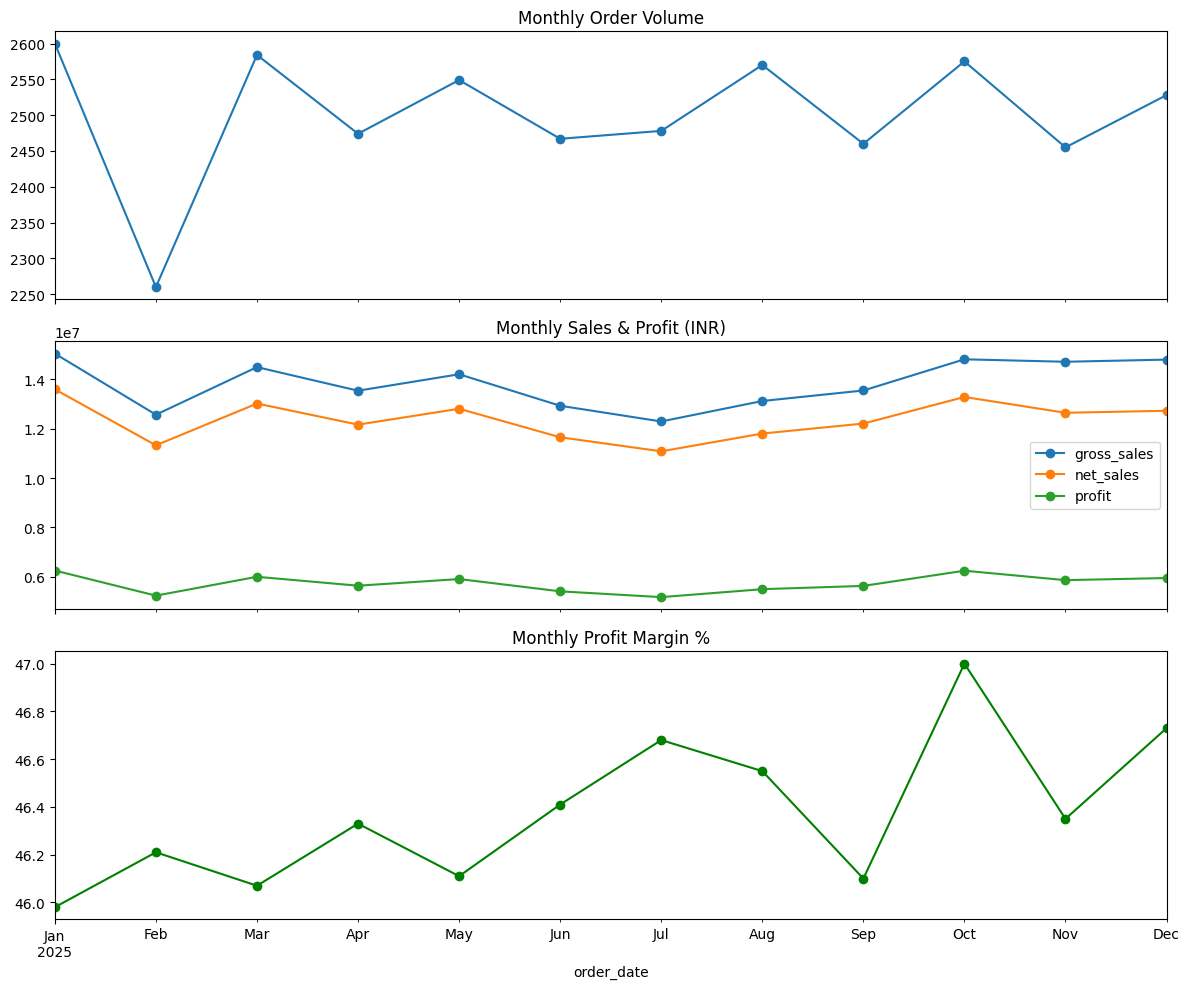

In [92]:
fig, axes = plt.subplots(3,1, figsize=(12,10), sharex=True)
monthly['orders'].plot(ax=axes[0], marker='o', title='Monthly Order Volume')
monthly[['gross_sales','net_sales','profit']].plot(ax=axes[1], marker='o', title='Monthly Sales & Profit (INR)')
monthly['profit_margin_pct'].plot(ax=axes[2], marker='o', color='green', title='Monthly Profit Margin %')
plt.tight_layout()
plt.show()

In [93]:
# peak/dip flag
print("Peak month:", monthly['net_sales'].idxmax(), monthly['net_sales'].max())
print("Lowest month:", monthly['net_sales'].idxmin(), monthly['net_sales'].min())

Peak month: 2025-01-31 00:00:00 13599527.85
Lowest month: 2025-07-31 00:00:00 11085158.74


profits and shares are not always very directly corelated. oct gave a slightly high profit but jan has more products moving.

#**Product & Category Performance**

In [94]:
category_perf = data_df.groupby('category').agg(
    orders=('order_id','count'),
    net_sales=('net_sales_inr','sum'),
    profit=('profit_inr','sum'),
    avg_discount_pct=('discount_pct','mean')
)
category_perf['contribution_pct'] = (category_perf['net_sales'] / category_perf['net_sales'].sum() * 100).round(2)
category_perf['profit_margin_pct'] = (category_perf['profit'] / category_perf['net_sales'] * 100).round(2)
category_perf.sort_values('net_sales', ascending=False)

,orders,net_sales,profit,avg_discount_pct,contribution_pct,profit_margin_pct
category,,,,,,
Electronics,2520,63904887.56,25751804.20,12.915520,43.08,40.30
Fashion,4968,21777125.61,10878207.12,13.008977,14.68,49.95
Home & Kitchen,3282,20469000.88,10010884.98,13.061395,13.80,48.91
Sports & Fitness,3444,14657450.34,7454903.63,13.045311,9.88,50.86
Beauty & Personal Care,4539,11094908.40,5641925.88,13.060033,7.48,50.85
Toys & Kids,1703,4019406.28,2152518.06,13.085725,2.71,53.55
Books & Stationery,3026,3943559.25,2326651.54,12.958493,2.66,59.00
Grocery,4034,3716203.61,1977322.88,12.932479,2.51,53.21
Health & Wellness,1716,3575135.63,1963014.35,12.880181,2.41,54.91


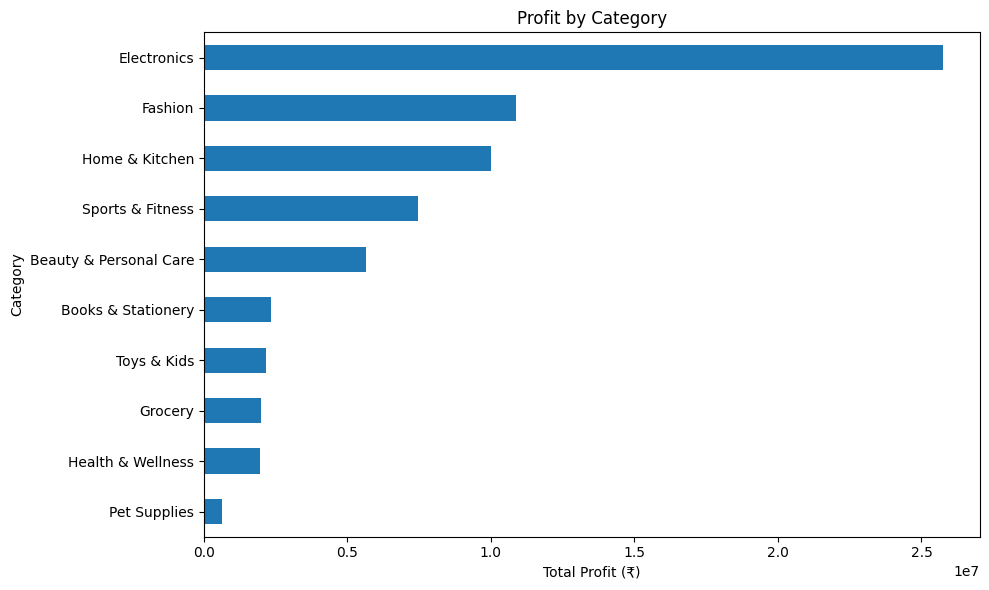

In [95]:
plt.figure(figsize=(10, 6))

category_perf['profit'].sort_values().plot(kind='barh')

plt.title('Profit by Category')
plt.xlabel('Total Profit (₹)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [96]:
# top products by profit and by revenue
product_performance = data_df.groupby('product_id').agg(
    net_sales=('net_sales_inr','sum'),
    profit=('profit_inr','sum'),
    orders=('order_id','count'),
    avg_discount_pct=('discount_pct','mean'),
    avg_rating=('rating','mean'),
    category=('category','first')
).sort_values('profit', ascending=False)

In [97]:
#top 10
product_performance.head(10)


,net_sales,profit,orders,avg_discount_pct,avg_rating,category
product_id,,,,,,
P0084,15164162.20,6105799.23,248,13.405927,4.083333,Electronics
P0089,9902244.69,4018640.09,243,13.461481,4.097778,Electronics
P0081,7303701.09,2931433.08,278,12.228777,4.084942,Electronics
P0002,5823318.78,2356931.42,256,12.817930,4.121212,Electronics
P0067,5483694.87,2211119.27,259,12.161313,4.045455,Electronics
P0082,5302782.91,2161075.07,251,12.644781,4.054393,Electronics
P0110,4713956.27,1885772.86,232,13.831509,4.149038,Electronics
P0007,3097908.28,1593745.28,257,13.047393,4.141079,Fashion
P0041,3000689.78,1539151.35,267,12.875768,4.106122,Fashion


In [98]:
#bottom 10
product_performance.tail(15)

,net_sales,profit,orders,avg_discount_pct,avg_rating,category
product_id,,,,,,
P0120,295846.01,133097.99,280,12.928321,4.138996,Beauty & Personal Care
P0056,258305.76,124180.90,230,13.730739,4.084112,Toys & Kids
P0083,221492.34,115634.97,262,13.385763,4.169492,Grocery
P0005,219529.34,114287.52,269,12.548141,4.111570,Grocery
P0117,235695.25,108826.64,259,12.857799,4.153527,Toys & Kids
P0046,187104.94,99695.41,240,12.932833,4.095023,Books & Stationery
P0017,167825.98,79089.69,260,12.826000,4.100806,Grocery
P0063,164488.27,79085.24,254,12.142953,4.135802,Grocery
P0051,161387.26,78922.56,235,12.877404,4.152381,Grocery


top performer is electronics both product and category, but bottom is a bit mixed, category says pet supplies but most of the bottom products are groceries. actual profits at this point could not be the only source of eveluation

In [99]:
category_profit = data_df.groupby('category').agg(
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum'),
    orders=('order_id', 'count'))

category_profit['profit_margin_pct'] = (
    category_profit['profit'] / category_profit['net_sales'] * 100).round(2)

category_profit.sort_values('profit', ascending=False)

,net_sales,profit,orders,profit_margin_pct
category,,,,
Electronics,63904887.56,25751804.20,2520,40.30
Fashion,21777125.61,10878207.12,4968,49.95
Home & Kitchen,20469000.88,10010884.98,3282,48.91
Sports & Fitness,14657450.34,7454903.63,3444,50.86
Beauty & Personal Care,11094908.40,5641925.88,4539,50.85
Books & Stationery,3943559.25,2326651.54,3026,59.00
Toys & Kids,4019406.28,2152518.06,1703,53.55
Grocery,3716203.61,1977322.88,4034,53.21
Health & Wellness,3575135.63,1963014.35,1716,54.91


groceries has a good margin, so maybe,it could be generating less total profit comparitively. Electronics sells in smaller volume but high priced so larger profits but  groceries are high volume low price and high margin

In [100]:
category_order_value = data_df.groupby('category').agg(
    avg_units=('units', 'mean'),
    avg_unit_price=('unit_price_inr', 'mean'),
    avg_sales_per_order=('net_sales_inr', 'mean')).round(2)

category_order_value.sort_values('avg_sales_per_order', ascending=False)

,avg_units,avg_unit_price,avg_sales_per_order
category,,,
Electronics,1.81,15608.69,25359.08
Home & Kitchen,1.82,3776.04,6236.75
Fashion,1.81,2661.52,4383.48
Sports & Fitness,1.81,2562.61,4255.94
Beauty & Personal Care,1.83,1429.80,2444.35
Toys & Kids,1.86,1349.12,2360.19
Health & Wellness,1.83,1206.15,2083.41
Pet Supplies,1.83,895.58,1552.10
Books & Stationery,1.78,752.32,1303.23


confirms electronic has small oeders(low units) but high profits for each order and vise versa for groceries

In [101]:
category_economics = data_df.groupby('category').agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum'))

category_economics['sales_per_order'] = (
    category_economics['net_sales'] / category_economics['orders']).round(2)

category_economics['profit_per_order'] = (
    category_economics['profit'] / category_economics['orders']).round(2)

category_economics.sort_values('profit_per_order', ascending=False)

,orders,net_sales,profit,sales_per_order,profit_per_order
category,,,,,
Electronics,2520,63904887.56,25751804.20,25359.08,10218.97
Home & Kitchen,3282,20469000.88,10010884.98,6236.75,3050.24
Fashion,4968,21777125.61,10878207.12,4383.48,2189.66
Sports & Fitness,3444,14657450.34,7454903.63,4255.94,2164.61
Toys & Kids,1703,4019406.28,2152518.06,2360.19,1263.96
Beauty & Personal Care,4539,11094908.40,5641925.88,2444.35,1242.99
Health & Wellness,1716,3575135.63,1963014.35,2083.41,1143.95
Pet Supplies,768,1192013.38,639196.42,1552.10,832.29
Books & Stationery,3026,3943559.25,2326651.54,1303.23,768.89


electronics has stronger order economics

#**Discounts and profits**

In [102]:
data_df['discount_pct'].min(), data_df['discount_pct'].max()

(0.0, 30.0)

In [103]:
bins = [-0.1, 10, 20, 30, 100]
labels = ['0-10%','10-20%','20-30%','30%+']
data_df['discount_band'] = pd.cut(data_df['discount_pct'], bins=bins, labels=labels)

discount_perf = data_df.groupby('discount_band').agg(
    orders=('order_id','count'),
    net_sales=('net_sales_inr','sum'),
    profit=('profit_inr','sum'))
discount_perf['profit_margin_pct'] = (discount_perf['profit'] / discount_perf['net_sales'] * 100).round(2)
discount_perf

/tmp/ipykernel_124495/1591622064.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_perf = data_df.groupby('discount_band').agg(


,orders,net_sales,profit,profit_margin_pct
discount_band,,,,
0-10%,10170,54603202.05,25560919.33,46.81
10-20%,15400,74738824.06,34624384.41,46.33
20-30%,4430,19007664.83,8611125.32,45.30
30%+,0,0.00,0.00,NaN


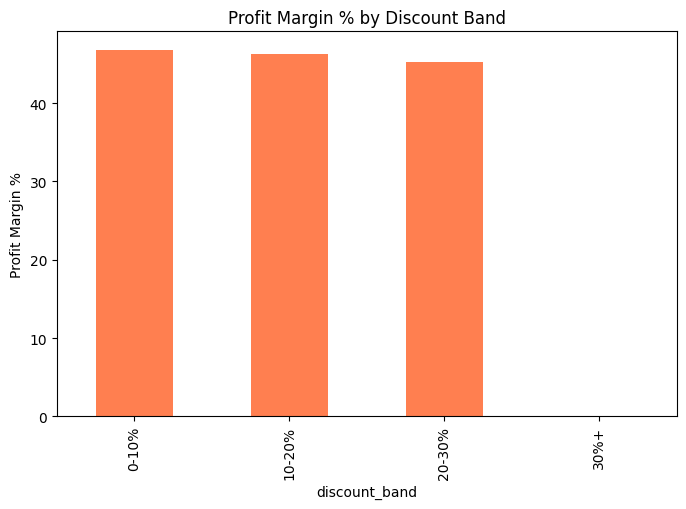

In [104]:
fig, ax = plt.subplots(figsize=(8,5))
discount_perf['profit_margin_pct'].plot(kind='bar', ax=ax, color='coral')
plt.title('Profit Margin % by Discount Band')
plt.ylabel('Profit Margin %')
plt.show()

theres a gradual dip in profit margin wit increase in discounts

In [105]:
corr = data_df[['discount_pct','profit_inr']].corr().iloc[0,1]
corr

np.float64(-0.05498434977285512)

suggests a weak correlation so only discounts are not the major factor affecting profits

In [106]:
data_df.groupby(['category','discount_band'])['profit_inr'].mean().unstack()

/tmp/ipykernel_124495/1725741908.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_df.groupby(['category','discount_band'])['profit_inr'].mean().unstack()


discount_band,0-10%,10-20%,20-30%,30%+
category,,,,
Beauty & Personal Care,1387.158311,1207.891902,1041.143787,NaN
Books & Stationery,840.124247,758.349311,637.451579,NaN
Electronics,10962.491507,10101.212800,8860.746125,NaN
Fashion,2430.111051,2125.879410,1866.981831,NaN
Grocery,541.093731,487.436488,380.392141,NaN
Health & Wellness,1254.521729,1113.136253,985.601321,NaN
Home & Kitchen,3325.245137,3022.569445,2521.084519,NaN
Pet Supplies,897.333571,830.695985,707.688908,NaN
Sports & Fitness,2421.592837,2080.317414,1881.420918,NaN


discounts are mostly between 10-30% and the pattern is almost same accross all categories no evidence that discounts for a particular category has significance on other

In [107]:
discount_volume = data_df.groupby('discount_band').agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum'))

discount_volume['order_share_pct'] = (discount_volume['orders'] / discount_volume['orders'].sum() * 100).round(2)
discount_volume['sales_per_order'] = (discount_volume['net_sales'] / discount_volume['orders']).round(2)
discount_volume['profit_per_order'] = (discount_volume['profit'] / discount_volume['orders']).round(2)
discount_volume


/tmp/ipykernel_124495/2359614818.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_volume = data_df.groupby('discount_band').agg(


,orders,net_sales,profit,order_share_pct,sales_per_order,profit_per_order
discount_band,,,,,,
0-10%,10170,54603202.05,25560919.33,33.90,5369.05,2513.36
10-20%,15400,74738824.06,34624384.41,51.33,4853.17,2248.34
20-30%,4430,19007664.83,8611125.32,14.77,4290.67,1943.82
30%+,0,0.00,0.00,0.00,NaN,NaN


10-20% is the mostly ordered band but we cannot conclude yet that this discount increased the orders beacuse the higest band has low orders

In [108]:
discount_category = data_df.groupby(
    ['category', 'discount_band']
).agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum'))

discount_category['order_share_pct'] = (
    discount_category['orders']
    / discount_category.groupby(level=0)['orders'].transform('sum')
    * 100).round(2)

discount_category['profit_per_order'] = (
    discount_category['profit']
    / discount_category['orders']).round(2)

discount_category

/tmp/ipykernel_124495/246069237.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_category = data_df.groupby(


orders    net_sales       profit  \
category               discount_band                                     
Beauty & Personal Care 0-10%            1510   4034070.66   2094609.05   
                       10-20%           2361   5630002.58   2851832.78   
                       20-30%            668   1430835.16    695484.05   
                       30%+                0         0.00         0.00   
Books & Stationery     0-10%            1036   1430748.15    870368.72   
                       10-20%           1553   2005991.88   1177716.48   
                       20-30%            437    506819.22    278566.34   
                       30%+                0         0.00         0.00   
Electronics            0-10%             876  23825173.13   9603142.56   
                       10-20%           1275  31923856.09  12879046.32   
                       20-30%            369   8155858.34   3269615.32   
                       30%+                0         0.00         0.00   
Fashion                0-10%            1655   7948580.29   4021833.79   
                       10-20%           2592  11072526.93   5510279.43   
                       20-30%            721   2756018.39   1346093.90   
                       30%+                0         0.00         0.00   
Grocery                0-10%            1426   1385519.10    771599.66   
                       10-20%           1996   1837894.96    972923.23   
                       20-30%            612    492789.55    232799.99   
                       30%+                0         0.00         0.00   
Health & Wellness      0-10%             613   1372033.75    769021.82   
                       10-20%            838   1707645.86    932808.18   
                       20-30%            265    495456.02    261184.35   
                       30%+                0         0.00         0.00   
Home & Kitchen         0-10%            1092   7364026.58   3631167.69   
                       10-20%           1712  10573025.95   5174638.89   
                       20-30%            478   2531948.35   1205078.40   
                       30%+                0         0.00         0.00   
Pet Supplies           0-10%             238    386541.84    213565.39   
                       10-20%            411    639413.61    341416.05   
                       20-30%            119    166057.93     84214.98   
                       30%+                0         0.00         0.00   
Sports & Fitness       0-10%            1149   5384565.38   2782410.17   
                       10-20%           1783   7332605.83   3709205.95   
                       20-30%            512   1940279.13    963287.51   
                       30%+                0         0.00         0.00   
Toys & Kids            0-10%             575   1471943.17    803200.48   
                       10-20%            879   2015860.37   1074517.10   
                       20-30%            249    531602.74    274800.48   
                       30%+                0         0.00         0.00   

                                      order_share_pct  profit_per_order  
category               discount_band                                     
Beauty & Personal Care 0-10%                    33.27           1387.16  
                       10-20%                   52.02           1207.89  
                       20-30%                   14.72           1041.14  
                       30%+                      0.00               NaN  
Books & Stationery     0-10%                    34.24            840.12  
                       10-20%                   51.32            758.35  
                       20-30%                   14.44            637.45  
                       30%+                      0.00               NaN  
Electronics            0-10%                    34.76          10962.49  
                       10-20%                   50.60          10101.21  
                       20-30%            

discount behaviour is fairly consistent accross categories. May be depending on demand, could this be changed for categories?

In [109]:
customer_discount = data_df.groupby(
    ['customer_segment', 'discount_band']
).agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum'))

customer_discount['order_share_pct'] = (
    customer_discount['orders']
    / customer_discount.groupby(level=0)['orders'].transform('sum')
    * 100).round(2)

customer_discount['profit_per_order'] = (
    customer_discount['profit']
    / customer_discount['orders']).round(2)

customer_discount

/tmp/ipykernel_124495/2256454919.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_discount = data_df.groupby(


orders    net_sales       profit  \
customer_segment discount_band                                     
New              0-10%            4098  21272507.39   9878632.57   
                 10-20%           9170  43372057.46  20093195.38   
                 20-30%           3214  13277173.49   6026695.42   
                 30%+                0         0.00         0.00   
Returning        0-10%            4676  24667749.43  11567265.22   
                 10-20%           5256  25068824.83  11613155.60   
                 20-30%           1055   4825340.41   2174832.27   
                 30%+                0         0.00         0.00   
VIP              0-10%            1396   8662945.23   4115021.54   
                 10-20%            974   6297941.77   2918033.43   
                 20-30%            161    905150.93    409597.63   
                 30%+                0         0.00         0.00   

                                order_share_pct  profit_per_order  
customer_segment discount_band                                     
New              0-10%                    24.86           2410.60  
                 10-20%                   55.64           2191.19  
                 20-30%                   19.50           1875.14  
                 30%+                      0.00               NaN  
Returning        0-10%                    42.56           2473.75  
                 10-20%                   47.84           2209.50  
                 20-30%                    9.60           2061.45  
                 30%+                      0.00               NaN  
VIP              0-10%                    55.16           2947.72  
                 10-20%                   38.48           2995.93  
                 20-30%                    6.36           2544.08  
                 30%+                      0.00               NaN

new customers get relatively high discounts ( 55% in 20-30% bin) and returning and vip get mostly low discounts so are we using high discounts to attract and convert them into returning?

#**Customer analysis**

In [110]:
customer_perf = data_df.groupby('customer_segment').agg(
    orders=('order_id','count'),
    unique_customers=('customer_id','nunique'),
    net_sales=('net_sales_inr','sum'),
    profit=('profit_inr','sum'))
customer_perf['aov'] = (customer_perf['net_sales'] / customer_perf['orders']).round(2)
customer_perf['orders_per_customer'] = (customer_perf['orders'] / customer_perf['unique_customers']).round(2)
customer_perf['revenue_contribution_pct'] = (customer_perf['net_sales'] / customer_perf['net_sales'].sum() * 100).round(2)
customer_perf['profit_contribution_pct'] = (customer_perf['profit'] / customer_perf['profit'].sum() * 100).round(2)
customer_perf

,orders,unique_customers,net_sales,profit,aov,orders_per_customer,revenue_contribution_pct,profit_contribution_pct
customer_segment,,,,,,,,
New,16482,4307,77921738.34,35998523.37,4727.69,3.83,52.53,52.33
Returning,10987,2850,54561914.67,25355253.09,4966.04,3.86,36.78,36.86
VIP,2531,670,15866037.93,7442652.60,6268.68,3.78,10.70,10.82


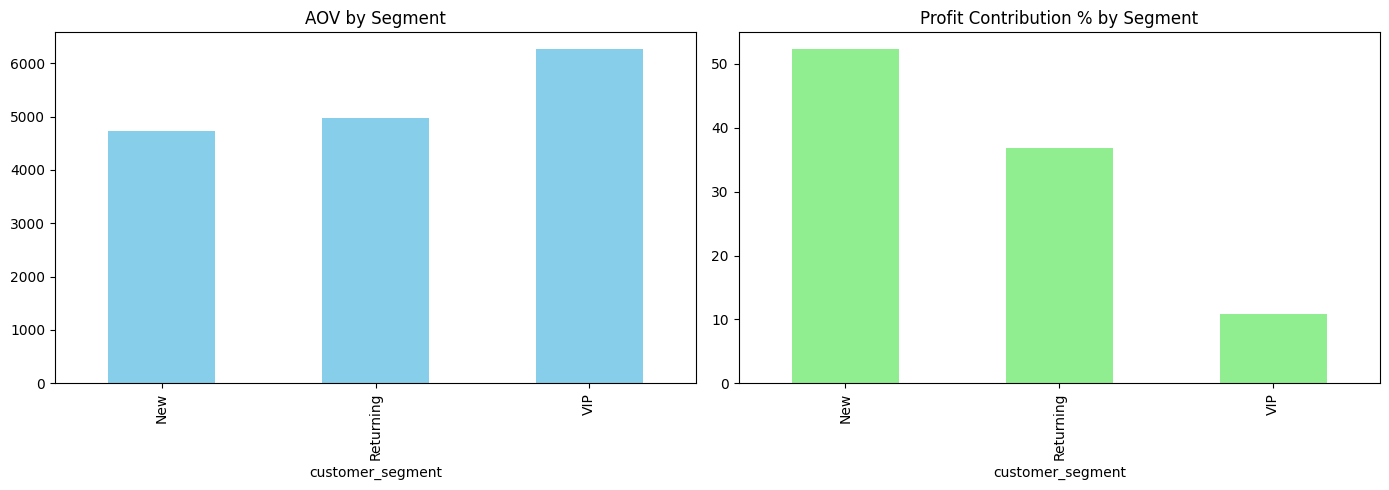

In [111]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
customer_perf['aov'].plot(kind='bar', ax=axes[0], title='AOV by Segment', color='skyblue')
customer_perf['profit_contribution_pct'].plot(kind='bar', ax=axes[1], title='Profit Contribution % by Segment', color='lightgreen')
plt.tight_layout()
plt.show()

vip have high avo (make more valuable oders) but new has the largest revernue and profit contribution

#**Channel and Campaign**

In [112]:
channel_perf = data_df.groupby('acquisition_channel').agg(
    orders=('order_id','count'),
    net_sales=('net_sales_inr','sum'),
    profit=('profit_inr','sum'),
    marketing_cost=('marketing_allocated_inr','sum'))
channel_perf['cost_per_order'] = (channel_perf['marketing_cost'] / channel_perf['orders']).round(2)

channel_perf['marketing_efficiency'] = channel_perf.apply(
    lambda r: round(r['profit']/r['marketing_cost'],2) if r['marketing_cost']>0 else np.nan, axis=1)
channel_perf.sort_values('profit', ascending=False)

,orders,net_sales,profit,marketing_cost,cost_per_order,marketing_efficiency
acquisition_channel,,,,,,
Organic Search,6583,32365811.02,15404764.20,0.00,0.00,NaN
Direct,5952,30495695.16,14311615.87,104136.66,17.50,137.43
Paid Search,6036,28814435.11,12900011.04,697966.67,115.63,18.48
Social,4884,22639630.65,10402026.76,420267.17,86.05,24.75
Email,3518,18719859.97,8721932.63,106717.71,30.33,81.73
Affiliate,3027,15314259.03,7056078.56,125481.01,41.45,56.23


direct has high profit with low marketting cost and organic has the highest with zero marketting cost(we confirmed earlier)

In [113]:
#discount
channel_discount = data_df.groupby(
    ['acquisition_channel', 'customer_segment', 'discount_band']
).agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum'))

channel_discount['order_share_pct'] = (
    channel_discount['orders']
    / channel_discount.groupby(
        level=[0, 1]
    )['orders'].transform('sum')
    * 100).round(2)

channel_discount['profit_per_order'] = (
    channel_discount['profit']
    / channel_discount['orders']).round(2)

channel_discount

/tmp/ipykernel_124495/2400804879.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  channel_discount = data_df.groupby(


orders   net_sales  \
acquisition_channel customer_segment discount_band                       
Affiliate           New              0-10%             173   846057.25   
                                     10-20%            895  4648263.39   
                                     20-30%            587  2546834.84   
                                     30%+                0        0.00   
                    Returning        0-10%             257  1390014.89   
...                                                    ...         ...   
Social              Returning        30%+                0        0.00   
                    VIP              0-10%             128   954622.55   
                                     10-20%            225  1436184.01   
                                     20-30%             51   277732.10   
                                     30%+                0        0.00   

                                                        profit  \
acquisition_channel customer_segment discount_band               
Affiliate           New              0-10%           393029.26   
                                     10-20%         2138817.42   
                                     20-30%         1161675.56   
                                     30%+                 0.00   
                    Returning        0-10%           645383.58   
...                                                        ...   
Social              Returning        30%+                 0.00   
                    VIP              0-10%           444871.12   
                                     10-20%          671168.57   
                                     20-30%          130906.29   
                                     30%+                 0.00   

                                                    order_share_pct  \
acquisition_channel customer_segment discount_band                    
Affiliate           New              0-10%                    10.45   
                                     10-20%                   54.08   
                                     20-30%                   35.47   
                                     30%+                      0.00   
                    Returning        0-10%                    23.24   
...                                                             ...   
Social              Returning        30%+                      0.00   
                    VIP              0-10%                    31.68   
                                     10-20%                   55.69   
                                     20-30%                   12.62   
                                     30%+                      0.00   

                                                    profit_per_order  
acquisition_channel customer_segment discount_band                    
Affiliate           New              0-10%                   2271.85  
                                     10-20%                  2389.74  
                                     20-30%                  1979.00  
                                     30%+                        NaN  
                    Returning        0-10%                   2511.22  
...                                                              ...  
Social              Returning        30%+                        NaN  
                    VIP              0-10%                   3475.56  
                                     10-20%                  2982.97  
                                     20-30%                  2566.79  
                                     30%+                        NaN  

[72 rows x 5 columns]

In [114]:
channel_discount_summary = data_df.groupby(
    ['acquisition_channel', 'customer_segment', 'discount_band'],
    observed=False).agg(
    orders=('order_id', 'count'),
    profit_per_order=('profit_inr', 'mean')).reset_index()

channel_discount_summary['order_share_pct'] = (
    channel_discount_summary['orders']
    / channel_discount_summary.groupby(
        ['acquisition_channel', 'customer_segment']
    )['orders'].transform('sum')* 100).round(2)

channel_discount_summary[
    ['acquisition_channel', 'customer_segment',
     'discount_band', 'orders',
     'order_share_pct', 'profit_per_order']]

,acquisition_channel,customer_segment,discount_band,orders,order_share_pct,profit_per_order
0,Affiliate,New,0-10%,173,10.45,2271.845434
1,Affiliate,New,10-20%,895,54.08,2389.740134
2,Affiliate,New,20-30%,587,35.47,1979.004361
3,Affiliate,New,30%+,0,0.00,NaN
4,Affiliate,Returning,0-10%,257,23.24,2511.220156
...,...,...,...,...,...,...
67,Social,Returning,30%+,0,0.00,NaN
68,Social,VIP,0-10%,128,31.68,3475.555625
69,Social,VIP,10-20%,225,55.69,2982.971422
70,Social,VIP,20-30%,51,12.62,2566.790000


In [115]:
discount_mix = channel_discount_summary.pivot_table(
    index=['acquisition_channel', 'customer_segment'],
    columns='discount_band',
    values='order_share_pct',
    fill_value=0,
    observed=False
).round(2)

discount_mix

discount_band                         0-10%  10-20%  20-30%  30%+
acquisition_channel customer_segment                             
Affiliate           New               10.45   54.08   35.47   0.0
                    Returning         23.24   58.68   18.08   0.0
                    VIP               32.33   54.14   13.53   0.0
Direct              New               38.13   55.98    5.89   0.0
                    Returning         59.11   39.14    1.75   0.0
                    VIP               75.30   24.50    0.20   0.0
Email               New               35.41   58.15    6.44   0.0
                    Returning         58.87   39.01    2.11   0.0
                    VIP               71.28   28.37    0.35   0.0
Organic Search      New               37.73   57.63    4.64   0.0
                    Returning         60.17   38.64    1.20   0.0
                    VIP               76.50   22.97    0.53   0.0
Paid Search         New               10.97   52.55   36.48   0.0
                    Returning         20.82   59.95   19.22   0.0
                    VIP               33.59   53.01   13.40   0.0
Social              New               10.29   55.51   34.19   0.0
                    Returning         24.76   56.02   19.22   0.0
                    VIP               31.68   55.69   12.62   0.0

new customers mostly acquired via affiliate marketting/paid search/social has more no. of discounted orders and note these also has high marketing cost

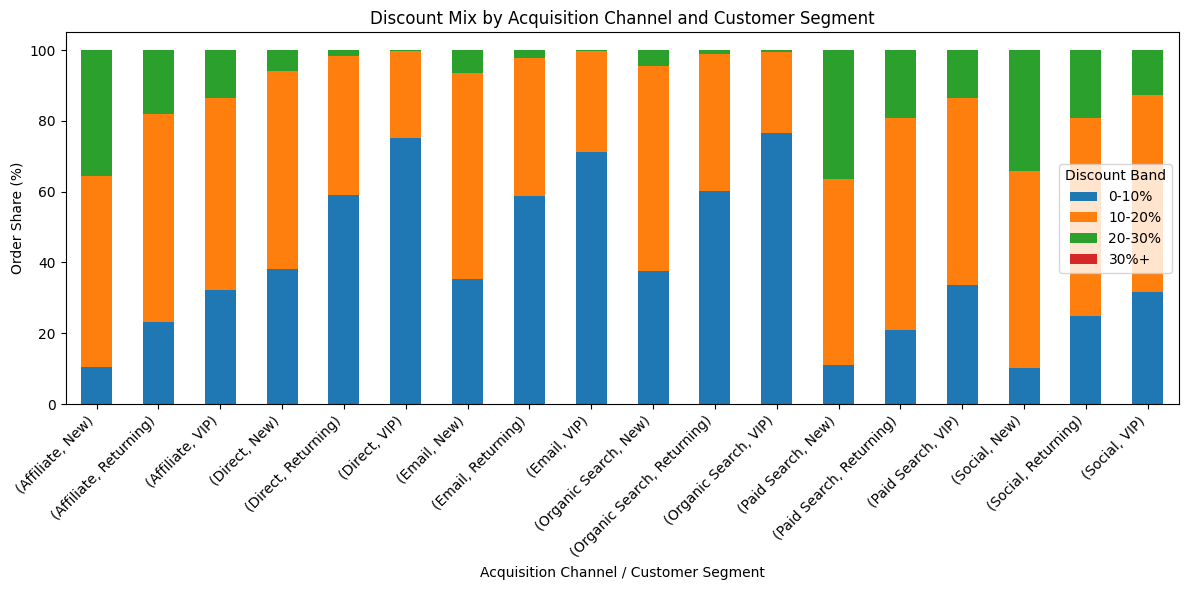

In [116]:
discount_mix.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Discount Mix by Acquisition Channel and Customer Segment')
plt.xlabel('Acquisition Channel / Customer Segment')
plt.ylabel('Order Share (%)')
plt.legend(title='Discount Band')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#**Delivery and logistics**

In [117]:
data_df['on_time_flag'] = (data_df['delivery_status'] == 'On Time').astype(int)
data_df['delay_days'] = data_df['actual_delivery_days'] - data_df['promised_delivery_days']

ops_warehouse = data_df.groupby('warehouse').agg(
    orders=('order_id','count'),
    on_time_pct=('on_time_flag','mean'),
    avg_delay=('delay_days','mean'))
ops_warehouse['on_time_pct'] = (ops_warehouse['on_time_pct']*100).round(2)
ops_warehouse

,orders,on_time_pct,avg_delay
warehouse,,,
WH-BLR,4101,62.89,0.101439
WH-DEL,3625,64.77,0.064000
WH-HYD,3295,55.14,0.338695
WH-JAI,2957,45.35,0.612445
WH-KOL,3541,55.13,0.332392
WH-LKO,3040,50.92,0.463158
WH-MUM,4916,60.90,0.170464
WH-NCR,4525,61.92,0.137459


In [118]:
ops_seller_tier = data_df.groupby('seller_tier').agg(
    orders=('order_id','count'),
    on_time_pct=('on_time_flag','mean'),
    avg_delay=('delay_days','mean')
)
ops_seller_tier['on_time_pct'] = (ops_seller_tier['on_time_pct']*100).round(2)
ops_seller_tier

,orders,on_time_pct,avg_delay
seller_tier,,,
Bronze,4307,51.82,0.404458
Gold,9331,59.75,0.212089
Platinum,3333,60.40,0.184818
Silver,13029,58.03,0.251976


High seller tier(platinum) has lower delyas in delivery

In [119]:
ops_geo = data_df.groupby('city_tier').agg(
    orders=('order_id','count'),
    on_time_pct=('on_time_flag','mean'),
    avg_delay=('delay_days','mean')
)
ops_geo['on_time_pct'] = (ops_geo['on_time_pct']*100).round(2)
ops_geo

,orders,on_time_pct,avg_delay
city_tier,,,
Tier 1,10824,60.09,0.197339
Tier 2,10538,59.73,0.202031
Tier 3,8638,53.06,0.388400


tire 3 cities(outter) has delays as expected, could be area and facility of transpotation, warehousing problems - must be addressed

In [120]:
warehouse_citytier = data_df.groupby(
    ['warehouse', 'city_tier']
).agg(
    orders=('order_id', 'count'),
    on_time_pct=('on_time_flag', 'mean'),
    avg_delay=('delay_days', 'mean')
)

warehouse_citytier['on_time_pct'] = (
    warehouse_citytier['on_time_pct'] * 100
).round(2)

warehouse_citytier['avg_delay'] = (
    warehouse_citytier['avg_delay']
).round(2)

warehouse_citytier

orders  on_time_pct  avg_delay
warehouse city_tier                                
WH-BLR    Tier 1       1496        65.31       0.05
          Tier 2       1439        64.14       0.03
          Tier 3       1166        58.23       0.25
WH-DEL    Tier 1       1312        68.06      -0.02
          Tier 2       1289        67.03       0.00
          Tier 3       1024        57.71       0.25
WH-HYD    Tier 1       1150        55.57       0.30
          Tier 2       1156        57.44       0.29
          Tier 3        989        51.97       0.44
WH-JAI    Tier 1       1082        46.95       0.56
          Tier 2       1000        47.00       0.57
          Tier 3        875        41.49       0.73
WH-KOL    Tier 1       1272        58.65       0.26
          Tier 2       1240        56.53       0.29
          Tier 3       1029        49.08       0.48
WH-LKO    Tier 1       1100        55.45       0.36
          Tier 2       1099        50.23       0.45
          Tier 3        841        45.90       0.60
WH-MUM    Tier 1       1795        61.95       0.13
          Tier 2       1732        64.38       0.11
          Tier 3       1389        55.22       0.30
WH-NCR    Tier 1       1617        63.02       0.11
          Tier 2       1583        63.49       0.08
          Tier 3       1325        58.72       0.24

high delays in tire 3 cities accross most of the warehouse. so its a common problem and is not the only contributor to the weakness of DEL and JAI, could be other reasons contributing as well


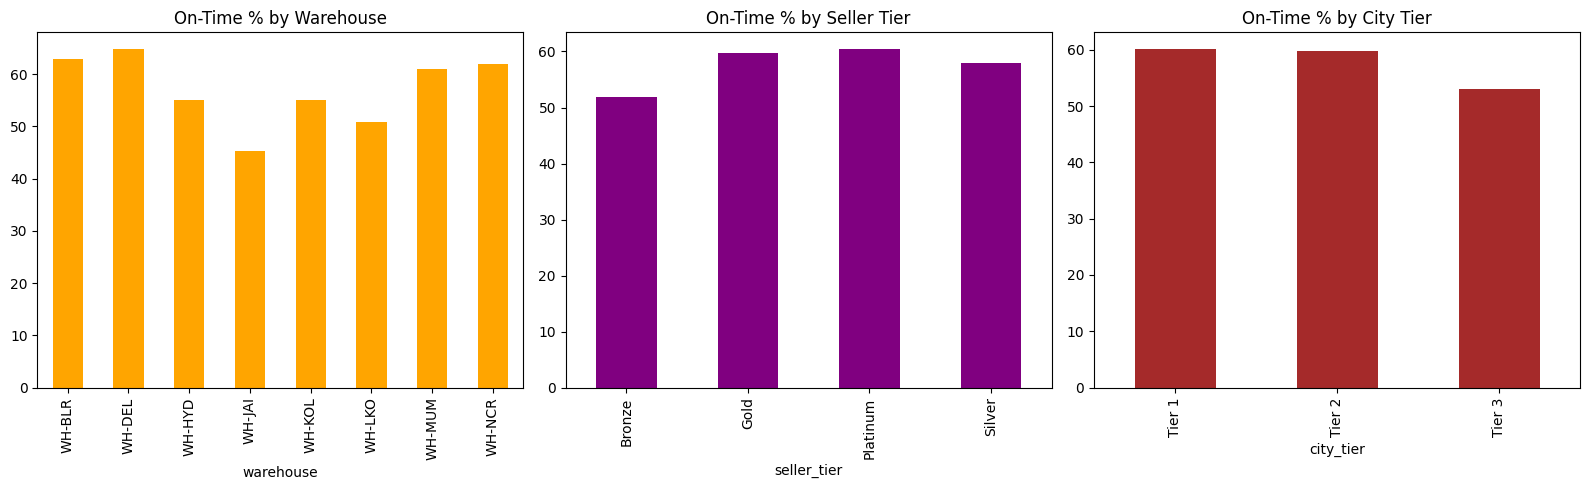

In [121]:
fig, axes = plt.subplots(1,3, figsize=(16,5))
ops_warehouse['on_time_pct'].plot(kind='bar', ax=axes[0], title='On-Time % by Warehouse', color='orange')
ops_seller_tier['on_time_pct'].plot(kind='bar', ax=axes[1], title='On-Time % by Seller Tier', color='purple')
ops_geo['on_time_pct'].plot(kind='bar', ax=axes[2], title='On-Time % by City Tier', color='brown')
plt.tight_layout()
plt.show()

#**Returns & Ratings**

*already infered that processing, returned or cancled orders has no ratings and is valid for these cases*

In [122]:
return_by_cat = data_df.groupby('category')['return_flag'].mean().mul(100).round(2).sort_values(ascending=False)
return_by_channel = data_df.groupby('acquisition_channel')['return_flag'].mean().mul(100).round(2).sort_values(ascending=False)
return_by_seller_tier = data_df.groupby('seller_tier')['return_flag'].mean().mul(100).round(2).sort_values(ascending=False)

In [123]:
#by category
return_by_cat

,return_flag
category,
Fashion,7.91
Electronics,7.66
Home & Kitchen,5.70
Sports & Fitness,5.60
Health & Wellness,5.54
Grocery,5.50
Beauty & Personal Care,5.38
Books & Stationery,4.96
Toys & Kids,4.64


fashion has high returns - due to quality/size/color or other cosmetic reasons

In [124]:
#dist channel
return_by_channel

,return_flag
acquisition_channel,
Social,6.31
Paid Search,6.30
Affiliate,6.21
Email,6.11
Direct,5.63
Organic Search,5.54


almost all channels has the similar return rates

In [125]:
#by seller
return_by_seller_tier

,return_flag
seller_tier,
Platinum,6.54
Bronze,6.25
Silver,5.92
Gold,5.71


high end seller has most returns?

In [126]:
return_reason = data_df[data_df['return_flag']==1]['return_reason'].value_counts()
return_reason

,count
return_reason,
Not as Expected,412
Late Delivery,352
Wrong Item,269
Damaged,268
Size/Fit Issue,264
Changed Mind,226


returns due to not as expected could indicate a very important and potent problem - false marketting (fake reviews/ratings/photos)

In [127]:
return_reason_channel = data_df[data_df['return_flag'] == 1].groupby(['acquisition_channel', 'return_reason']).size().unstack(fill_value=0)
return_reason_channel

return_reason,Changed Mind,Damaged,Late Delivery,Not as Expected,Size/Fit Issue,Wrong Item
acquisition_channel,,,,,,
Affiliate,25,24,35,48,35,21
Direct,41,52,67,76,45,54
Email,29,45,40,38,35,28
Organic Search,49,55,81,76,48,56
Paid Search,52,49,71,91,44,73
Social,30,43,58,83,57,37


paid search and affiliate has high not expected so false marketting could be a reason and must be inspected

In [128]:
return_reason_category = data_df[data_df['return_flag'] == 1].groupby( ['category', 'return_reason']).size().unstack(fill_value=0)
return_reason_category

return_reason,Changed Mind,Damaged,Late Delivery,Not as Expected,Size/Fit Issue,Wrong Item
category,,,,,,
Beauty & Personal Care,36,36,53,53,32,34
Books & Stationery,16,16,31,42,23,22
Electronics,27,29,44,37,28,28
Fashion,58,69,66,81,58,61
Grocery,32,25,43,56,35,31
Health & Wellness,6,16,21,27,15,10
Home & Kitchen,23,22,36,48,27,31
Pet Supplies,2,8,5,9,7,4
Sports & Fitness,20,33,34,41,30,35


we know fashin has high returns and as speculated its due to cosmetic reasons (not as expected - color/shape/material- damaged etc)size issues mostly. electronsi with almost same has a delivery delay issue potentially

In [129]:
return_reason_category_pct = (return_reason_category
.div(return_reason_category.sum(axis=1), axis=0) * 100).round(2)

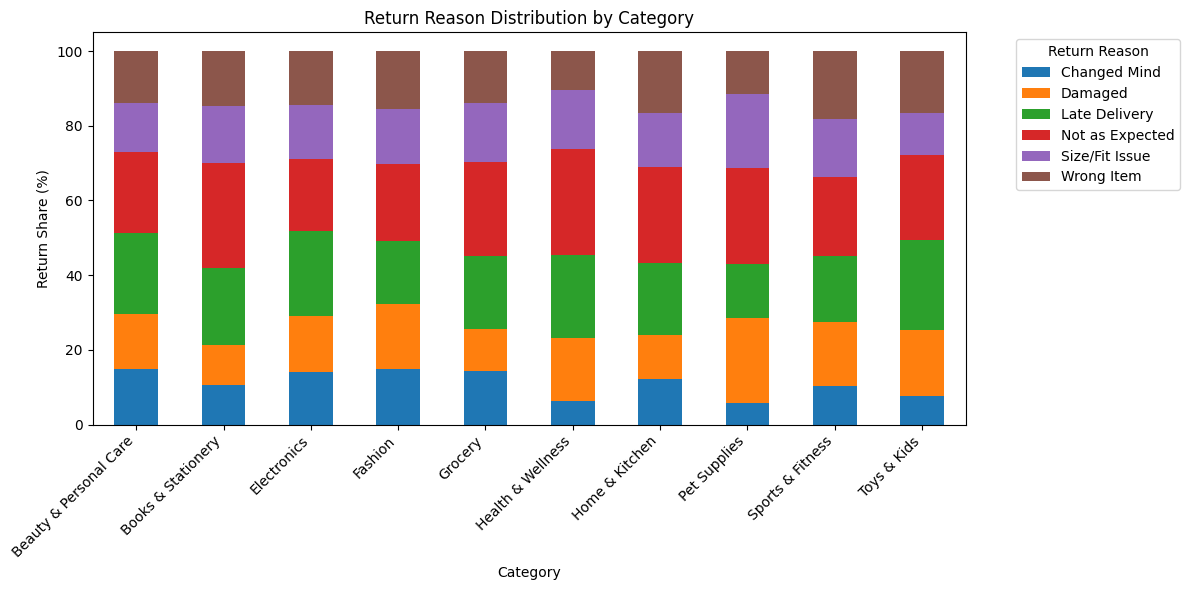

In [130]:
return_reason_category_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6))

plt.title('Return Reason Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Return Share (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Return Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [131]:
#Export

In [132]:

print("Final shape:", data_df.shape)
print("Nulls remaining:\n", data_df.isnull().sum()[data_df.isnull().sum() > 0])

Final shape: (30000, 45)
Nulls remaining:
 return_reason    28209
rating            1914
coupon_code      15116
campaign_id       6583
dtype: int64


In [133]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 0 to 29999
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_id                 30000 non-null  object        
 1   order_date               30000 non-null  datetime64[ns]
 2   customer_id              30000 non-null  object        
 3   customer_state           30000 non-null  object        
 4   customer_city            30000 non-null  object        
 5   city_tier                30000 non-null  object        
 6   customer_age             30000 non-null  float64       
 7   customer_segment         30000 non-null  object        
 8   acquisition_channel      30000 non-null  object        
 9   device_type              30000 non-null  object        
 10  product_id               30000 non-null  object        
 11  category                 30000 non-null  object        
 12  seller_id                30000 non-nu

In [134]:
data_df.head(5)

,order_id,order_date,customer_id,customer_state,customer_city,city_tier,customer_age,customer_segment,acquisition_channel,device_type,...,coupon_code,campaign_id,expected_discount,profit_calc,profit_diff,realized_sales_inr,realized_profit_inr,discount_band,on_time_flag,delay_days
0,QC25020800001,2025-02-08,C06480,Bihar,Patna,Tier 2,39.0,Returning,Direct,Mobile,...,SAVE10,CMP-09,222.633450,1171.13,0.0,2198.96,1171.13,0-10%,0,2
1,QC25071900002,2025-07-19,C06197,Uttar Pradesh,Lucknow,Tier 2,22.0,Returning,Email,Mobile,...,FESTIVE20,CMP-03,782.889800,1900.27,-0.0,4393.06,1900.27,10-20%,1,-1
2,QC25112100003,2025-11-21,C02829,Karnataka,Mangaluru,Tier 3,44.0,Returning,Affiliate,Mobile,...,SAVE10,CMP-04,399.114788,1457.98,0.0,2760.45,1457.98,10-20%,0,1
3,QC25032500004,2025-03-25,C04132,Kerala,Thiruvananthapuram,Tier 3,18.0,Returning,Direct,Mobile,...,NaN,CMP-09,498.618942,2348.80,0.0,4342.11,2348.80,10-20%,1,-1
4,QC25112800005,2025-11-28,C01137,Maharashtra,Nagpur,Tier 2,35.0,VIP,Paid Search,Desktop,...,SAVE10,CMP-10,89.237085,1152.16,0.0,2337.25,1152.16,0-10%,1,0


In [135]:
helper_cols_to_check = ['discount_band']
data_df.drop(columns=[c for c in helper_cols_to_check if c in data_df.columns], inplace=True)
data_df.head()

,order_id,order_date,customer_id,customer_state,customer_city,city_tier,customer_age,customer_segment,acquisition_channel,device_type,...,rating,coupon_code,campaign_id,expected_discount,profit_calc,profit_diff,realized_sales_inr,realized_profit_inr,on_time_flag,delay_days
0,QC25020800001,2025-02-08,C06480,Bihar,Patna,Tier 2,39.0,Returning,Direct,Mobile,...,5.0,SAVE10,CMP-09,222.633450,1171.13,0.0,2198.96,1171.13,0,2
1,QC25071900002,2025-07-19,C06197,Uttar Pradesh,Lucknow,Tier 2,22.0,Returning,Email,Mobile,...,4.0,FESTIVE20,CMP-03,782.889800,1900.27,-0.0,4393.06,1900.27,1,-1
2,QC25112100003,2025-11-21,C02829,Karnataka,Mangaluru,Tier 3,44.0,Returning,Affiliate,Mobile,...,4.0,SAVE10,CMP-04,399.114788,1457.98,0.0,2760.45,1457.98,0,1
3,QC25032500004,2025-03-25,C04132,Kerala,Thiruvananthapuram,Tier 3,18.0,Returning,Direct,Mobile,...,4.0,NaN,CMP-09,498.618942,2348.80,0.0,4342.11,2348.80,1,-1
4,QC25112800005,2025-11-28,C01137,Maharashtra,Nagpur,Tier 2,35.0,VIP,Paid Search,Desktop,...,5.0,SAVE10,CMP-10,89.237085,1152.16,0.0,2337.25,1152.16,1,0


In [136]:
data_df.to_csv('/content/quickcart_cleaned.csv', index=False)

#**Dashboard**

In [137]:
bins = [-0.1, 10, 20, 30, 100]
labels = ['0-10%', '10-20%', '20-30%', '30%+']

data_df['discount_band'] = pd.cut(
    data_df['discount_pct'],
    bins=bins,
    labels=labels
)

# Delivery analysis fields
data_df['on_time_flag'] = (
    data_df['delivery_status'] == 'On Time'
).astype(int)

data_df['delay_days'] = (
    data_df['actual_delivery_days']
    - data_df['promised_delivery_days']
)

In [148]:
#define KPIs



df = data_df.copy()

df['order_date'] = pd.to_datetime(df['order_date'])

# Discount bands already used in the analysis
bins = [-0.1, 10, 20, 30, 100]
labels = ['0-10%', '10-20%', '20-30%', '30%+']

df['discount_band'] = pd.cut(
    df['discount_pct'],
    bins=bins,
    labels=labels
)

# Delivery fields already used in the analysis
df['on_time_flag'] = (
    df['delivery_status'] == 'On Time'
).astype(int)

df['delay_days'] = (
    df['actual_delivery_days']
    - df['promised_delivery_days']
)


order_count = df['order_id'].count()

gross_sales = df['gross_sales_inr'].sum()
net_sales = df['net_sales_inr'].sum()
profit = df['profit_inr'].sum()

profit_margin = (
    profit / net_sales * 100
    if net_sales != 0 else np.nan
)

aov = (
    net_sales / order_count
    if order_count != 0 else np.nan
)

return_rate = df['return_flag'].mean() * 100
on_time_rate = df['on_time_flag'].mean() * 100

marketing_cost = df['marketing_allocated_inr'].sum()

marketing_efficiency = (
    profit / marketing_cost
    if marketing_cost > 0 else np.nan
)

In [141]:
!pip -q install plotly

In [149]:
#summary chart
df = data_df.copy()
# Monthly
monthly = (
    df.set_index('order_date')
      .resample('ME')
      .agg(
          orders=('order_id', 'count'),
          net_sales=('net_sales_inr', 'sum'),
          profit=('profit_inr', 'sum')
      )
)

monthly['profit_margin_pct'] = (
    monthly['profit'] / monthly['net_sales'] * 100
)

# Category
category = df.groupby('category').agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum'),
    avg_discount=('discount_pct', 'mean')
)

category['profit_margin_pct'] = (
    category['profit'] / category['net_sales'] * 100
)

category['contribution_pct'] = (
    category['net_sales'] / category['net_sales'].sum() * 100
)

category['aov'] = (
    category['net_sales'] / category['orders']
)

# Discount
discount = df.groupby(
    'discount_band',
    observed=False
).agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum')
)

discount['profit_margin_pct'] = (
    discount['profit'] / discount['net_sales'] * 100
)

discount['order_share_pct'] = (
    discount['orders'] / discount['orders'].sum() * 100
)

# Customer segment
segment = df.groupby('customer_segment').agg(
    orders=('order_id', 'count'),
    unique_customers=('customer_id', 'nunique'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum')
)

segment['aov'] = segment['net_sales'] / segment['orders']

segment['orders_per_customer'] = (
    segment['orders'] / segment['unique_customers']
)

segment['revenue_contribution_pct'] = (
    segment['net_sales'] / segment['net_sales'].sum() * 100
)

segment['profit_contribution_pct'] = (
    segment['profit'] / segment['profit'].sum() * 100
)

# Channel
channel = df.groupby('acquisition_channel').agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum'),
    marketing_cost=('marketing_allocated_inr', 'sum')
)

channel['cost_per_order'] = (
    channel['marketing_cost'] / channel['orders']
)

channel['marketing_efficiency'] = np.where(
    channel['marketing_cost'] > 0,
    channel['profit'] / channel['marketing_cost'],
    np.nan
)

# Warehouse
warehouse = df.groupby('warehouse').agg(
    orders=('order_id', 'count'),
    on_time_pct=('on_time_flag', 'mean')
)

warehouse['on_time_pct'] *= 100

# Average delay — delayed orders only
delayed = df[df['delivery_status'] == 'Delayed']

warehouse_delay = (
    delayed.groupby('warehouse')['delay_days']
    .mean()
)

warehouse['avg_delay_days'] = warehouse_delay

# Warehouse × city tier
warehouse_city = (
    df[df['delivery_status'] != 'Not Applicable']
    .groupby(['warehouse', 'city_tier'])
    .agg(
        orders=('order_id', 'count'),
        on_time_pct=('on_time_flag', 'mean'),
        avg_delay=('delay_days', 'mean')
    )
)

warehouse_city['on_time_pct'] *= 100

# Returns
return_category = df.groupby('category').agg(
    orders=('order_id', 'count'),
    return_rate=('return_flag', 'mean')
)

return_category['return_rate'] *= 100

return_channel = df.groupby('acquisition_channel').agg(
    orders=('order_id', 'count'),
    return_rate=('return_flag', 'mean')
)

return_channel['return_rate'] *= 100

return_seller = df.groupby('seller_tier').agg(
    orders=('order_id', 'count'),
    return_rate=('return_flag', 'mean')
)

return_seller['return_rate'] *= 100

# Ratings
rating_delivery = (
    df.groupby('delivery_status')['rating']
    .mean()
)

rating_return = (
    df.groupby('return_flag')['rating']
    .mean()
)

# Return reasons
return_reason = (
    df[df['return_flag'] == 1]['return_reason']
    .value_counts()
)

# Return reason × category — percentage within category
return_reason_category = (
    df[df['return_flag'] == 1]
    .groupby(['category', 'return_reason'])
    .size()
    .unstack(fill_value=0)
)

return_reason_category_pct = (
    return_reason_category
    .div(return_reason_category.sum(axis=1), axis=0)
    * 100
)

# Return reason × channel — percentage within channel
return_reason_channel = (
    df[df['return_flag'] == 1]
    .groupby(['acquisition_channel', 'return_reason'])
    .size()
    .unstack(fill_value=0)
)

return_reason_channel_pct = (
    return_reason_channel
    .div(return_reason_channel.sum(axis=1), axis=0)
    * 100
)

# ------------------------------------------------------------
# 4. SINGLE DASHBOARD FIGURE
# ------------------------------------------------------------

fig = make_subplots(
    rows=7,
    cols=2,
    specs=[
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
    ],
    subplot_titles=[
        "Monthly Net Sales & Profit",
        "Monthly Profit Margin",
        "Profit by Category",
        "Profit Margin by Category",
        "Discount Band vs Profit Margin",
        "AOV by Customer Segment",
        "Marketing Cost per Order",
        "Marketing Efficiency",
        "On-Time Delivery by Warehouse",
        "Average Delay by Warehouse — Delayed Orders Only",
        "Return Rate by Category",
        "Return Rate by Acquisition Channel",
        "Return Rate by Seller Tier",
        "Average Rating by Delivery Status",
    ],
    vertical_spacing=0.055,
    horizontal_spacing=0.08
)

#month based

fig.add_trace(
    go.Scatter(
        x=monthly.index,
        y=monthly['net_sales'],
        mode='lines+markers',
        name='Net Sales',
        hovertemplate='Net Sales: ₹%{y:,.0f}<extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly.index,
        y=monthly['profit'],
        mode='lines+markers',
        name='Profit',
        hovertemplate='Profit: ₹%{y:,.0f}<extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly.index,
        y=monthly['profit_margin_pct'],
        mode='lines+markers',
        name='Margin',
        hovertemplate='Margin: %{y:.2f}%<extra></extra>'
    ),
    row=1, col=2
)
#category

cat_profit = category.sort_values('profit')

fig.add_trace(
    go.Bar(
        x=cat_profit['profit'],
        y=cat_profit.index,
        orientation='h',
        name='Profit',
        hovertemplate='Profit: ₹%{x:,.0f}<extra></extra>'
    ),
    row=2, col=1
)

cat_margin = category.sort_values('profit_margin_pct')

fig.add_trace(
    go.Bar(
        x=cat_margin['profit_margin_pct'],
        y=cat_margin.index,
        orientation='h',
        name='Margin',
        hovertemplate='Margin: %{x:.2f}%<extra></extra>'
    ),
    row=2, col=2
)

#discount and customer

fig.add_trace(
    go.Scatter(
        x=discount.index.astype(str),
        y=discount['profit_margin_pct'],
        mode='lines+markers',
        name='Profit Margin',
        hovertemplate='Margin: %{y:.2f}%<extra></extra>'
    ),
    row=3, col=1
)

fig.add_trace(
    go.Bar(
        x=segment.index,
        y=segment['aov'],
        name='AOV',
        hovertemplate='AOV: ₹%{y:,.0f}<extra></extra>'
    ),
    row=3, col=2
)

#channel
channel_cost = channel.sort_values('cost_per_order')

fig.add_trace(
    go.Bar(
        x=channel_cost['cost_per_order'],
        y=channel_cost.index,
        orientation='h',
        name='Cost / Order',
        hovertemplate='Cost / Order: ₹%{x:,.2f}<extra></extra>'
    ),
    row=4, col=1
)

channel_eff = channel.dropna(
    subset=['marketing_efficiency']
).sort_values('marketing_efficiency')

fig.add_trace(
    go.Bar(
        x=channel_eff['marketing_efficiency'],
        y=channel_eff.index,
        orientation='h',
        name='Marketing Efficiency',
        hovertemplate='Efficiency: %{x:.2f}<extra></extra>'
    ),
    row=4, col=2
)

#operation

warehouse_sorted = warehouse.sort_values('on_time_pct')

fig.add_trace(
    go.Bar(
        x=warehouse_sorted['on_time_pct'],
        y=warehouse_sorted.index,
        orientation='h',
        name='On-Time %',
        hovertemplate='On-Time: %{x:.2f}%<extra></extra>'
    ),
    row=5, col=1
)

delay_sorted = warehouse.sort_values('avg_delay_days')

fig.add_trace(
    go.Bar(
        x=delay_sorted['avg_delay_days'],
        y=delay_sorted.index,
        orientation='h',
        name='Avg Delay',
        hovertemplate='Avg Delay: %{x:.2f} days<extra></extra>'
    ),
    row=5, col=2
)

#return

rc = return_category.sort_values('return_rate')

fig.add_trace(
    go.Bar(
        x=rc['return_rate'],
        y=rc.index,
        orientation='h',
        name='Return Rate',
        hovertemplate='Return Rate: %{x:.2f}%<extra></extra>'
    ),
    row=6, col=1
)

rch = return_channel.sort_values('return_rate')

fig.add_trace(
    go.Bar(
        x=rch['return_rate'],
        y=rch.index,
        orientation='h',
        name='Return Rate',
        hovertemplate='Return Rate: %{x:.2f}%<extra></extra>'
    ),
    row=6, col=2
)


# Tier + Ratings


rst = return_seller.sort_values('return_rate')

fig.add_trace(
    go.Bar(
        x=rst['return_rate'],
        y=rst.index,
        orientation='h',
        name='Return Rate',
        hovertemplate='Return Rate: %{x:.2f}%<extra></extra>'),row=7, col=1)

fig.add_trace(
    go.Bar(
        x=rating_delivery.index,
        y=rating_delivery.values,
        name='Average Rating',
        hovertemplate='Rating: %{y:.2f}<extra></extra>'),row=7, col=2)

#tiles
fig.update_yaxes(title_text="₹", row=1, col=1)
fig.update_yaxes(title_text="Margin %", row=1, col=2)

fig.update_xaxes(title_text="Profit (₹)", row=2, col=1)
fig.update_xaxes(title_text="Margin %", row=2, col=2)

fig.update_xaxes(title_text="Discount Band", row=3, col=1)
fig.update_yaxes(title_text="Margin %", row=3, col=1)

fig.update_yaxes(title_text="AOV (₹)", row=3, col=2)

fig.update_xaxes(title_text="₹ / Order", row=4, col=1)
fig.update_xaxes(title_text="Profit / Marketing Cost", row=4, col=2)

fig.update_xaxes(title_text="On-Time %", row=5, col=1)
fig.update_xaxes(title_text="Days", row=5, col=2)

fig.update_xaxes(title_text="Return Rate %", row=6, col=1)
fig.update_xaxes(title_text="Return Rate %", row=6, col=2)

fig.update_xaxes(title_text="Return Rate %", row=7, col=1)
fig.update_yaxes(title_text="Average Rating", row=7, col=2)

#kpi cards

kpis = [
    ("Orders", f"{order_count:,}"),
    ("Gross Sales", f"₹{gross_sales/1e7:.2f} Cr"),
    ("Net Sales", f"₹{net_sales/1e7:.2f} Cr"),
    ("Profit", f"₹{profit/1e7:.2f} Cr"),
    ("Profit Margin", f"{profit_margin:.2f}%"),
    ("AOV", f"₹{aov:,.0f}"),
    ("Return Rate", f"{return_rate:.2f}%"),
    ("On-Time Delivery", f"{on_time_rate:.2f}%"),]

# Add KPI annotations across the top
x_positions = [
    0.06, 0.18, 0.30, 0.42,
    0.54, 0.66, 0.78, 0.90]

for (label, value), x in zip(kpis, x_positions):
    fig.add_annotation(
        x=x,
        y=1.12,
        xref="paper",
        yref="paper",
        text=f"<b>{label}</b><br><span style='font-size:18px'>{value}</span>",
        showarrow=False,
        align="center",
        bordercolor="lightgray",
        borderwidth=1,
        borderpad=8,
        bgcolor="white")

#layout

fig.update_layout(
    title={
        'text': 'E-Commerce Business Performance Dashboard',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 26}
    },
    height=3000,
    width=1400,
    showlegend=False,
    template='plotly_white',
    margin=dict(t=180, l=80, r=60, b=80))

fig.show()



print("\nDashboard KPI Definitions")
print("-" * 60)
print("Net Sales              = sum(net_sales_inr)")
print("Gross Sales            = sum(gross_sales_inr)")
print("Profit                 = sum(profit_inr)")
print("Profit Margin %        = Profit / Net Sales × 100")
print("AOV                    = Net Sales / Order Count")
print("Return Rate %          = mean(return_flag) × 100")
print("On-Time Delivery %     = mean(delivery_status == 'On Time') × 100")
print("Marketing Efficiency   = Profit / Marketing Allocated")
print("\nNote: Marketing Efficiency is N/A for channels with zero allocated marketing cost.")
print("Note: Average delay is calculated for delayed orders only.")
print("Note: Findings are descriptive associations, not causal conclusions.")



Dashboard KPI Definitions
------------------------------------------------------------
Net Sales              = sum(net_sales_inr)
Gross Sales            = sum(gross_sales_inr)
Profit                 = sum(profit_inr)
Profit Margin %        = Profit / Net Sales × 100
AOV                    = Net Sales / Order Count
Return Rate %          = mean(return_flag) × 100
On-Time Delivery %     = mean(delivery_status == 'On Time') × 100
Marketing Efficiency   = Profit / Marketing Allocated

Note: Marketing Efficiency is N/A for channels with zero allocated marketing cost.
Note: Average delay is calculated for delayed orders only.
Note: Findings are descriptive associations, not causal conclusions.


In [150]:
df = data_df.copy()

df['order_date'] = pd.to_datetime(df['order_date'])
df['on_time'] = (df['delivery_status'] == 'On Time').astype(int)
df['delay_days'] = df['actual_delivery_days'] - df['promised_delivery_days']

df['discount_band'] = pd.cut(
    df['discount_pct'],
    bins=[-0.1, 10, 20, 30, 100],
    labels=['0-10%', '10-20%', '20-30%', '30%+']
)

orders = df['order_id'].count()
gross_sales = df['gross_sales_inr'].sum()
net_sales = df['net_sales_inr'].sum()
profit = df['profit_inr'].sum()
margin = profit / net_sales * 100
aov = net_sales / orders
return_rate = df['return_flag'].mean() * 100
on_time = df['on_time'].mean() * 100
marketing = df['marketing_allocated_inr'].sum()
marketing_eff = profit / marketing

monthly = df.groupby(df['order_date'].dt.to_period('M')).agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum')
)

monthly.index = monthly.index.astype(str)
monthly['margin'] = monthly['profit'] / monthly['net_sales'] * 100

cat = df.groupby('category').agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum'),
    avg_discount=('discount_pct', 'mean')
)

cat['margin'] = cat['profit'] / cat['net_sales'] * 100
cat['sales_share'] = cat['net_sales'] / net_sales * 100
cat['aov'] = cat['net_sales'] / cat['orders']

discount = df.groupby('discount_band', observed=False).agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum')
)

discount['margin'] = discount['profit'] / discount['net_sales'] * 100
discount['profit_per_order'] = discount['profit'] / discount['orders']
discount['sales_per_order'] = discount['net_sales'] / discount['orders']

segment = df.groupby('customer_segment').agg(
    orders=('order_id', 'count'),
    customers=('customer_id', 'nunique'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum')
)

segment['aov'] = segment['net_sales'] / segment['orders']
segment['orders_per_customer'] = segment['orders'] / segment['customers']
segment['sales_share'] = segment['net_sales'] / net_sales * 100
segment['profit_share'] = segment['profit'] / profit * 100

channel = df.groupby('acquisition_channel').agg(
    orders=('order_id', 'count'),
    net_sales=('net_sales_inr', 'sum'),
    profit=('profit_inr', 'sum'),
    marketing=('marketing_allocated_inr', 'sum')
)

channel['cost_per_order'] = channel['marketing'] / channel['orders']
channel['efficiency'] = np.where(
    channel['marketing'] > 0,
    channel['profit'] / channel['marketing'],
    np.nan
)

warehouse = df.groupby('warehouse').agg(
    orders=('order_id', 'count'),
    on_time=('on_time', 'mean')
)

warehouse['on_time'] *= 100

delayed = df[df['delivery_status'] == 'Delayed']

delay = delayed.groupby('warehouse')['delay_days'].mean().sort_values()

warehouse_city = df[df['delivery_status'] != 'Not Applicable'].pivot_table(
    index='warehouse',
    columns='city_tier',
    values='on_time',
    aggfunc='mean'
) * 100

seller = (
    df[df['delivery_status'] != 'Not Applicable']
    .groupby('seller_tier')['on_time']
    .mean() * 100
)

city = (
    df[df['delivery_status'] != 'Not Applicable']
    .groupby('city_tier')['on_time']
    .mean() * 100
)

return_cat = df.groupby('category')['return_flag'].mean() * 100
return_channel = df.groupby('acquisition_channel')['return_flag'].mean() * 100
return_seller = df.groupby('seller_tier')['return_flag'].mean() * 100
return_segment = df.groupby('customer_segment')['return_flag'].mean() * 100

reasons = df[df['return_flag'] == 1]['return_reason'].value_counts()

reason_cat = pd.crosstab(
    df.loc[df['return_flag'] == 1, 'category'],
    df.loc[df['return_flag'] == 1, 'return_reason'],
    normalize='index'
) * 100

reason_channel = pd.crosstab(
    df.loc[df['return_flag'] == 1, 'acquisition_channel'],
    df.loc[df['return_flag'] == 1, 'return_reason'],
    normalize='index'
) * 100

rating_delivery = df.groupby('delivery_status')['rating'].mean()
rating_return = df.groupby('return_flag')['rating'].mean()
rating_category = df.groupby('category')['rating'].mean()

fig = make_subplots(
    rows=14,
    cols=2,
    specs=[
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}]
    ],
    subplot_titles=[
        'Monthly Sales and Profit',
        'Monthly Profit Margin',
        'Category Profit',
        'Category Profit Margin',
        'Category Sales Contribution',
        'Average Discount by Category',
        'Discount Band Profit Margin',
        'Profit per Order by Discount',
        'Customer Segment Sales and Profit',
        'Customer Segment AOV',
        'Orders per Customer',
        'Channel Net Sales',
        'Channel Profit',
        'Marketing Cost per Order',
        'Marketing Efficiency',
        'Warehouse On-Time Delivery',
        'Warehouse Average Delay',
        'Warehouse x City Tier On-Time',
        'Seller Tier On-Time Delivery',
        'City Tier On-Time Delivery',
        'Return Rate by Category',
        'Return Rate by Channel',
        'Return Rate by Seller Tier',
        'Return Rate by Customer Segment',
        'Return Reasons',
        'Return Reasons by Category',
        'Return Reasons by Channel',
        'Average Rating by Delivery Status',
        'Average Rating by Return Status'
    ],
    vertical_spacing=0.03,
    horizontal_spacing=0.08
)

# Monthly sales and profit
fig.add_trace(
    go.Scatter(
        x=monthly.index,
        y=monthly['net_sales'],
        mode='lines+markers',
        name='Net Sales'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly.index,
        y=monthly['profit'],
        mode='lines+markers',
        name='Profit'
    ),
    row=1, col=1
)

# Monthly profit margin
fig.add_trace(
    go.Scatter(
        x=monthly.index,
        y=monthly['margin'],
        mode='lines+markers',
        name='Margin'
    ),
    row=1, col=2
)

# Category profit
x = cat.sort_values('profit')

fig.add_trace(
    go.Bar(
        x=x['profit'],
        y=x.index,
        orientation='h',
        name='Profit'
    ),
    row=2, col=1
)

# Category profit margin
x = cat.sort_values('margin')

fig.add_trace(
    go.Bar(
        x=x['margin'],
        y=x.index,
        orientation='h',
        name='Margin'
    ),
    row=2, col=2
)

# Category sales contribution
x = cat.sort_values('sales_share')

fig.add_trace(
    go.Bar(
        x=x['sales_share'],
        y=x.index,
        orientation='h',
        name='Sales Share'
    ),
    row=3, col=1
)

# Average discount by category
x = cat.sort_values('avg_discount')

fig.add_trace(
    go.Bar(
        x=x['avg_discount'],
        y=x.index,
        orientation='h',
        name='Discount'
    ),
    row=3, col=2
)

# Discount band profit margin
fig.add_trace(
    go.Scatter(
        x=discount.index.astype(str),
        y=discount['margin'],
        mode='lines+markers',
        name='Margin'
    ),
    row=4, col=1
)

# Profit per order by discount band
fig.add_trace(
    go.Bar(
        x=discount.index.astype(str),
        y=discount['profit_per_order'],
        name='Profit / Order'
    ),
    row=4, col=2
)

# Customer segment sales and profit contribution
fig.add_trace(
    go.Bar(
        x=segment.index,
        y=segment['sales_share'],
        name='Sales Share'
    ),
    row=5, col=1
)

fig.add_trace(
    go.Bar(
        x=segment.index,
        y=segment['profit_share'],
        name='Profit Share'
    ),
    row=5, col=1
)

# Customer segment AOV
fig.add_trace(
    go.Bar(
        x=segment.index,
        y=segment['aov'],
        name='AOV'
    ),
    row=5, col=2
)

# Orders per customer
fig.add_trace(
    go.Bar(
        x=segment.index,
        y=segment['orders_per_customer'],
        name='Orders / Customer'
    ),
    row=6, col=1
)

# Channel net sales
x = channel.sort_values('net_sales')

fig.add_trace(
    go.Bar(
        x=x.index,
        y=x['net_sales'],
        name='Net Sales'
    ),
    row=6, col=2
)

# Channel profit
x = channel.sort_values('profit')

fig.add_trace(
    go.Bar(
        x=x.index,
        y=x['profit'],
        name='Profit'
    ),
    row=7, col=1
)

# Marketing cost per order
x = channel.sort_values('cost_per_order')

fig.add_trace(
    go.Bar(
        x=x['cost_per_order'],
        y=x.index,
        orientation='h',
        name='Cost / Order'
    ),
    row=7, col=2
)

# Marketing efficiency
x = channel.dropna(subset=['efficiency']).sort_values('efficiency')

fig.add_trace(
    go.Bar(
        x=x['efficiency'],
        y=x.index,
        orientation='h',
        name='Efficiency'
    ),
    row=8, col=1
)

# Warehouse on-time delivery
x = warehouse.sort_values('on_time')

fig.add_trace(
    go.Bar(
        x=x['on_time'],
        y=x.index,
        orientation='h',
        name='On-Time %'
    ),
    row=8, col=2
)

# Warehouse average delay
fig.add_trace(
    go.Bar(
        x=delay.values,
        y=delay.index,
        orientation='h',
        name='Delay'
    ),
    row=9, col=1
)

# Warehouse and city tier on-time delivery
fig.add_trace(
    go.Heatmap(
        z=warehouse_city.values,
        x=warehouse_city.columns.astype(str),
        y=warehouse_city.index,
        text=np.round(warehouse_city.values, 1),
        texttemplate='%{text}%',
        colorscale='Blues'
    ),
    row=9, col=2
)

# Seller tier on-time delivery
fig.add_trace(
    go.Bar(
        x=seller.index,
        y=seller.values,
        name='Seller Tier'
    ),
    row=10, col=1
)

# City tier on-time delivery
fig.add_trace(
    go.Bar(
        x=city.index,
        y=city.values,
        name='City Tier'
    ),
    row=10, col=2
)

# Return rate by category
x = return_cat.sort_values()

fig.add_trace(
    go.Bar(
        x=x.values,
        y=x.index,
        orientation='h',
        name='Return Rate'
    ),
    row=11, col=1
)

# Return rate by channel
x = return_channel.sort_values()

fig.add_trace(
    go.Bar(
        x=x.values,
        y=x.index,
        orientation='h',
        name='Return Rate'
    ),
    row=11, col=2
)

# Return rate by seller tier
x = return_seller.sort_values()

fig.add_trace(
    go.Bar(
        x=x.values,
        y=x.index,
        orientation='h',
        name='Return Rate'
    ),
    row=12, col=1
)

#return rate by cusseg
x = return_segment.sort_values()

fig.add_trace(
    go.Bar(
        x=x.values,
        y=x.index,
        orientation='h',
        name='Return Rate'
    ),
    row=12, col=2
)

#return reasons
fig.add_trace(
    go.Bar(
        x=reasons.values,
        y=reasons.index,
        orientation='h',
        name='Returns'
    ),
    row=13, col=1
)

#return reasons by category
for reason in reason_cat.columns:
    fig.add_trace(
        go.Bar(
            x=reason_cat.index,
            y=reason_cat[reason],
            name=reason
        ),
        row=13, col=2
    )

#rReturn reasons by channel
for reason in reason_channel.columns:
    fig.add_trace(
        go.Bar(
            x=reason_channel.index,
            y=reason_channel[reason],
            name=reason
        ),
        row=14, col=1
    )

#avg rating by delivery status
fig.add_trace(
    go.Bar(
        x=rating_delivery.index,
        y=rating_delivery.values,
        name='Rating'
    ),
    row=14, col=2
)

fig.update_layout(
    title='E-Commerce Business Analysis Dashboard',
    height=5600,
    width=1400,
    template='plotly_white',
    showlegend=False,
    margin=dict(t=180, l=80, r=60, b=80)
)

fig.update_yaxes(title_text='₹', row=1, col=1)
fig.update_yaxes(title_text='%', row=1, col=2)

fig.update_xaxes(title_text='Profit (₹)', row=2, col=1)
fig.update_xaxes(title_text='Margin %', row=2, col=2)

fig.update_xaxes(title_text='Sales Contribution %', row=3, col=1)
fig.update_xaxes(title_text='Average Discount %', row=3, col=2)

fig.update_yaxes(title_text='Margin %', row=4, col=1)
fig.update_yaxes(title_text='Profit / Order (₹)', row=4, col=2)

fig.update_yaxes(title_text='Contribution %', row=5, col=1)
fig.update_yaxes(title_text='AOV (₹)', row=5, col=2)

fig.update_yaxes(title_text='Orders / Customer', row=6, col=1)
fig.update_yaxes(title_text='Net Sales (₹)', row=6, col=2)

fig.update_yaxes(title_text='Profit (₹)', row=7, col=1)
fig.update_xaxes(title_text='₹ / Order', row=7, col=2)

fig.update_xaxes(title_text='Profit / Marketing Cost', row=8, col=1)
fig.update_xaxes(title_text='On-Time %', row=8, col=2)

fig.update_xaxes(title_text='Average Delay (Days)', row=9, col=1)

fig.update_yaxes(title_text='On-Time %', row=10, col=1)
fig.update_yaxes(title_text='On-Time %', row=10, col=2)

fig.update_xaxes(title_text='Return Rate %', row=11, col=1)
fig.update_xaxes(title_text='Return Rate %', row=11, col=2)

fig.update_xaxes(title_text='Return Rate %', row=12, col=1)
fig.update_xaxes(title_text='Return Rate %', row=12, col=2)

fig.update_xaxes(title_text='Number of Returns', row=13, col=1)
fig.update_yaxes(title_text='Return Share %', row=13, col=2)

fig.update_yaxes(title_text='Return Share %', row=14, col=1)
fig.update_yaxes(title_text='Average Rating', row=14, col=2)

fig.add_annotation(
    x=0.5,
    y=1.04,
    xref='paper',
    yref='paper',
    text=(
        f"<b>Orders:</b> {orders:,} &nbsp;&nbsp; "
        f"<b>Gross Sales:</b> ₹{gross_sales/1e7:.2f} Cr &nbsp;&nbsp; "
        f"<b>Net Sales:</b> ₹{net_sales/1e7:.2f} Cr &nbsp;&nbsp; "
        f"<b>Profit:</b> ₹{profit/1e7:.2f} Cr &nbsp;&nbsp; "
        f"<b>Margin:</b> {margin:.2f}% &nbsp;&nbsp; "
        f"<b>AOV:</b> ₹{aov:,.0f} &nbsp;&nbsp; "
        f"<b>Return Rate:</b> {return_rate:.2f}% &nbsp;&nbsp; "
        f"<b>On-Time:</b> {on_time:.2f}%"
    ),
    showarrow=False,
    font=dict(size=14)
)

fig.show()